# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 2    |  |
| :-------------|:-------------|
| Isha Schneiders| 6384838 |
| Thibo Alders| 6581390 |
| Wout Zeilmaker| 6585043|

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['wout', 'isha']

## Opdracht 1: Planning.

| Planning Groep: 2     |Tijdstip / Tijdspanne  |
|---|---|
| kalibratie metingen | 11.00-11.15 |
| eigen algortime uitvoeren en ontwerpen | 11.15-12.30, 13.45-14.15 |
| algortime kiezen,testen en itereren | 14.15-16.30 |
| TU Pauze 1| 12.30-13.30 |


## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [2]
<img src="kalibratie opstelling echo.jpeg" width="400">

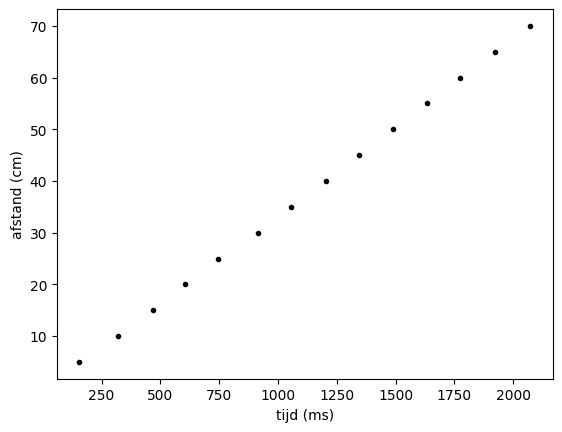

[ 0.03412922 -0.79298199]


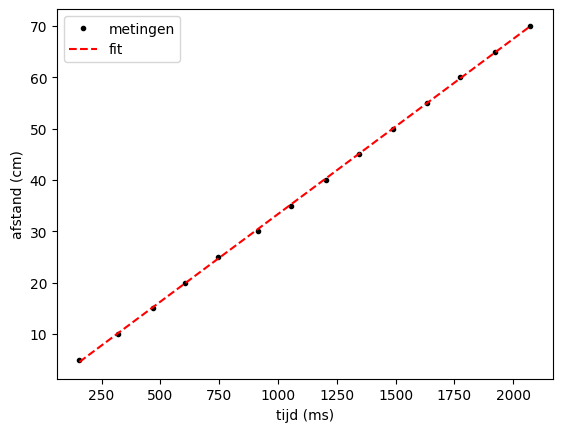

In [3]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

afstand=np.array([30,15,45,60,70,5,10,20,25,35,40,50,55,65]) #cm
tijd=np.array([915,468,1345,1774,2073,156,318,606,747,1057,1206,1488,1634,1921]) #ms

def lijn(x,a,b):
    return a*x+b

plt.figure()
plt.plot(tijd,afstand,"k.")
plt.xlabel('tijd (ms)')
plt.ylabel('afstand (cm)')
plt.show()

val,cov=curve_fit(lijn,tijd,afstand)
print(val)
x_plot=np.linspace(min(tijd),max(tijd))

plt.figure()
plt.plot(tijd,afstand,"k.",label="metingen")
plt.plot(x_plot,lijn(x_plot,*val),"r--",label="fit")
plt.xlabel('tijd (ms)')
plt.ylabel('afstand (cm)')
plt.legend()
plt.show()


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  44.6
1   0  30   0  20  44.6
2  40   0  30   0  43.2
3  30   0  20   0  43.1


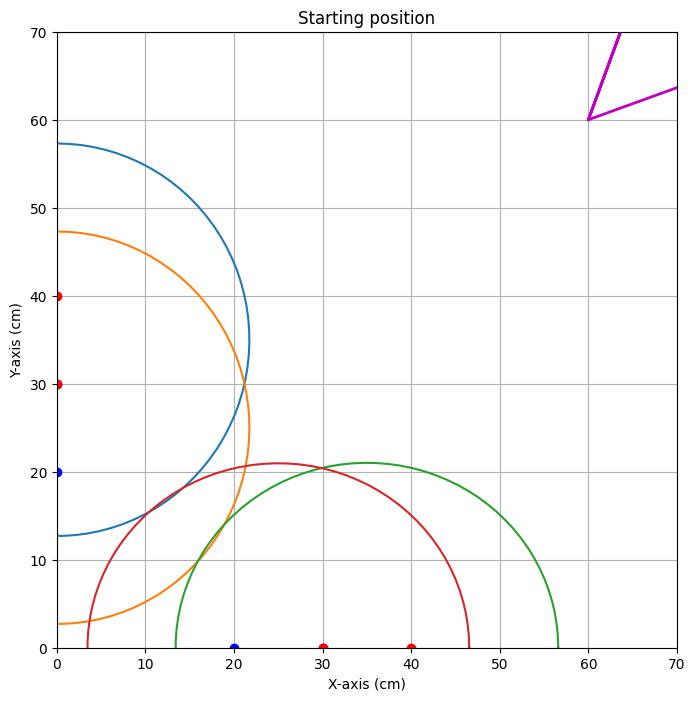


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=98.080


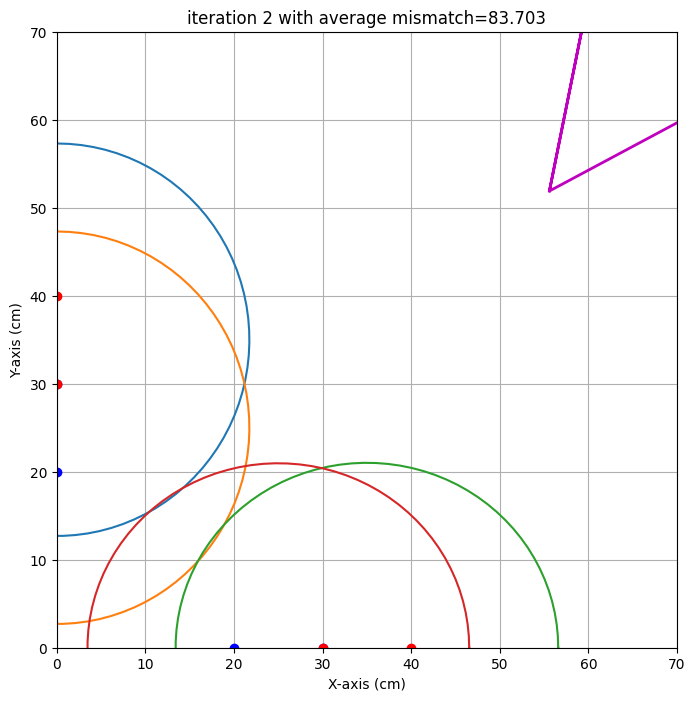

end iteration 2 with average mismatch=83.703


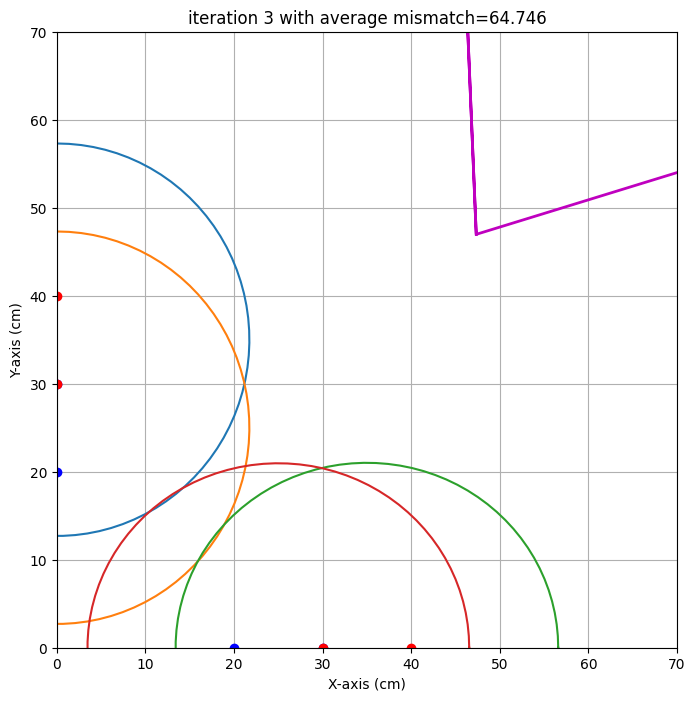

end iteration 3 with average mismatch=64.746


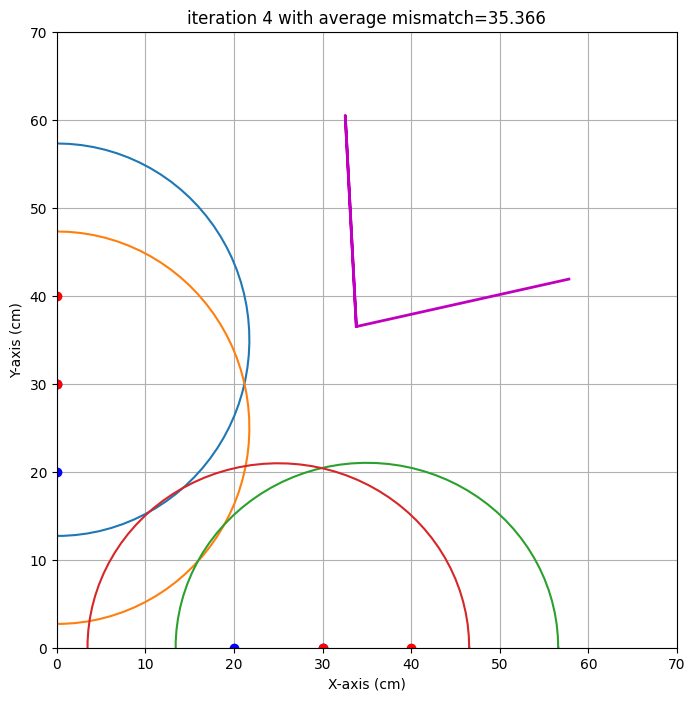

end iteration 4 with average mismatch=35.366


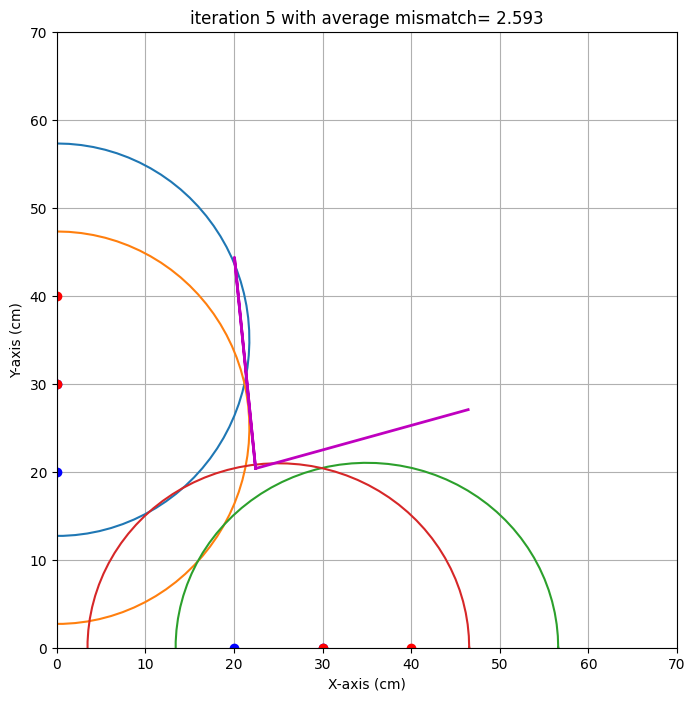

end iteration 5 with average mismatch= 2.593


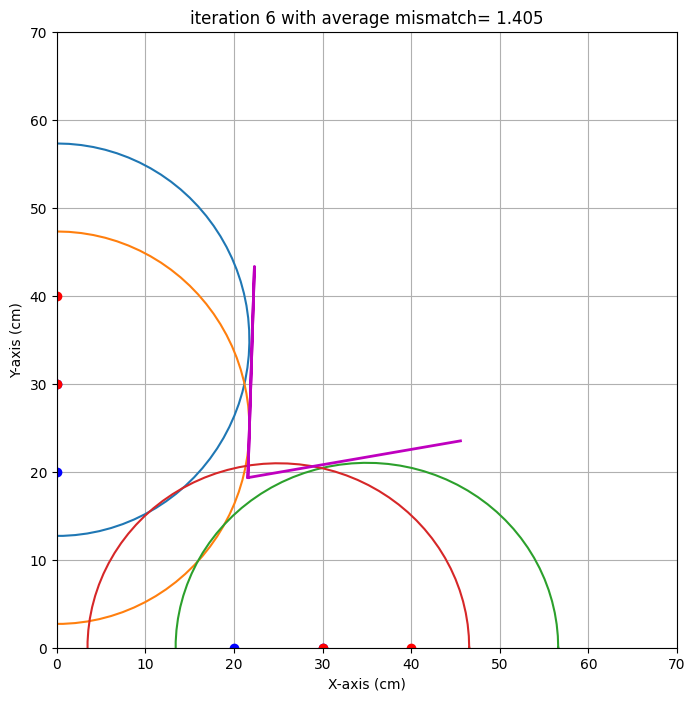

end iteration 6 with average mismatch= 1.405


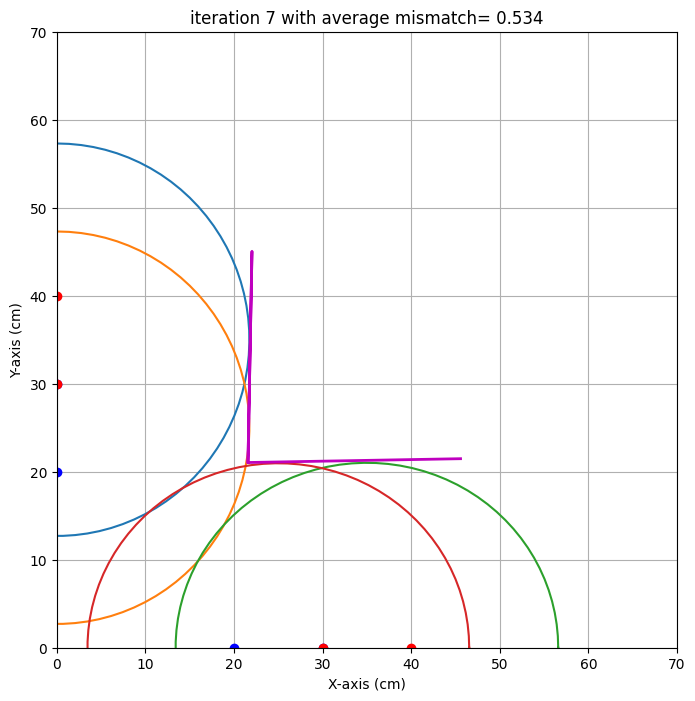

end iteration 7 with average mismatch= 0.534


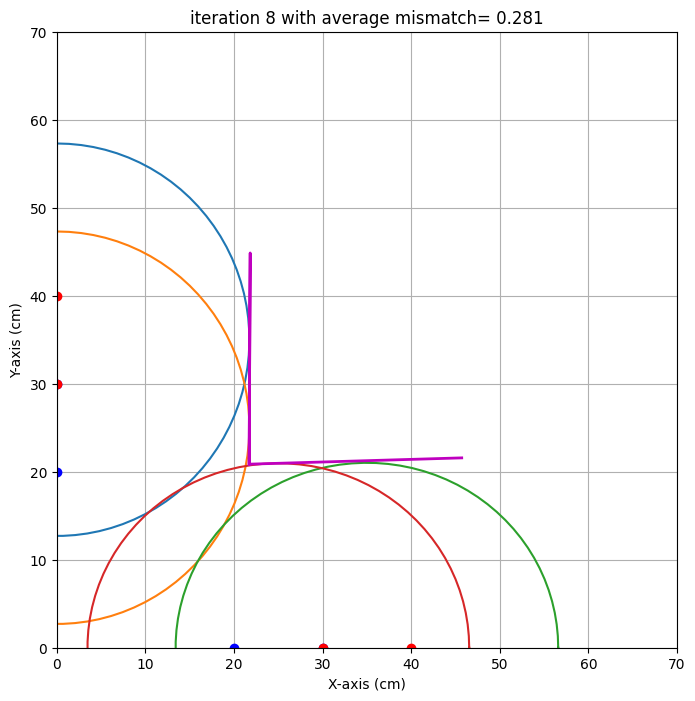

end iteration 8 with average mismatch= 0.281
end iteration 9 with average mismatch= 0.281
end iteration 10 with average mismatch= 0.281
end iteration 11 with average mismatch= 0.281
end iteration 12 with average mismatch= 0.281
end iteration 13 with average mismatch= 0.281
end iteration 14 with average mismatch= 0.281
end iteration 15 with average mismatch= 0.281
end iteration 16 with average mismatch= 0.281
end iteration 17 with average mismatch= 0.281
end iteration 18 with average mismatch= 0.281
end iteration 19 with average mismatch= 0.281
end iteration 20 with average mismatch= 0.281
end iteration 21 with average mismatch= 0.281
end iteration 22 with average mismatch= 0.281
end iteration 23 with average mismatch= 0.281
end iteration 24 with average mismatch= 0.281
end iteration 25 with average mismatch= 0.281
end iteration 26 with average mismatch= 0.281
end iteration 27 with average mismatch= 0.281
end iteration 28 with average mismatch= 0.281


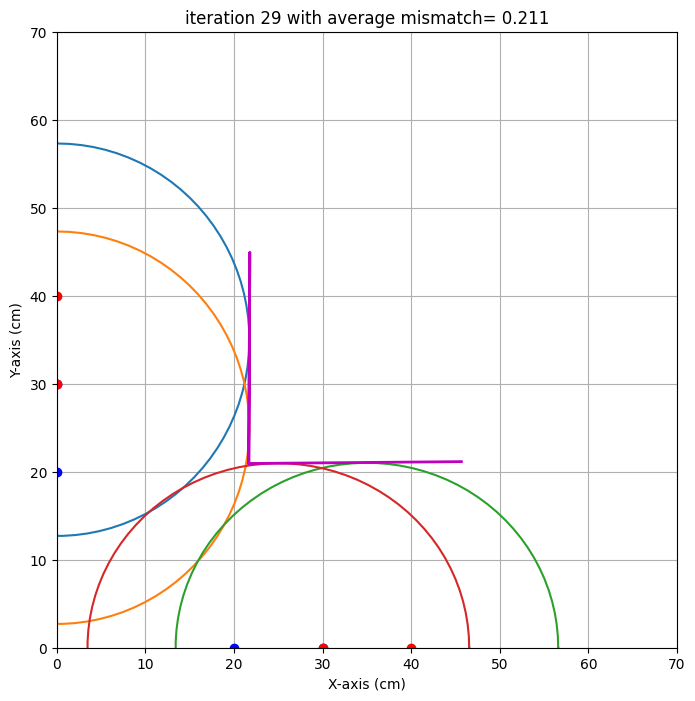

end iteration 29 with average mismatch= 0.211
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.202
###############################################################################
end of iteration  30
Best alpha=   0.50 with uncertainty=   0.23
Best beta =   0.27 with uncertainty=   0.25
Best x0   =  21.67 with uncertainty=   0.27
Best y0   =  20.93 with uncertainty=   0.27
###############################################################################


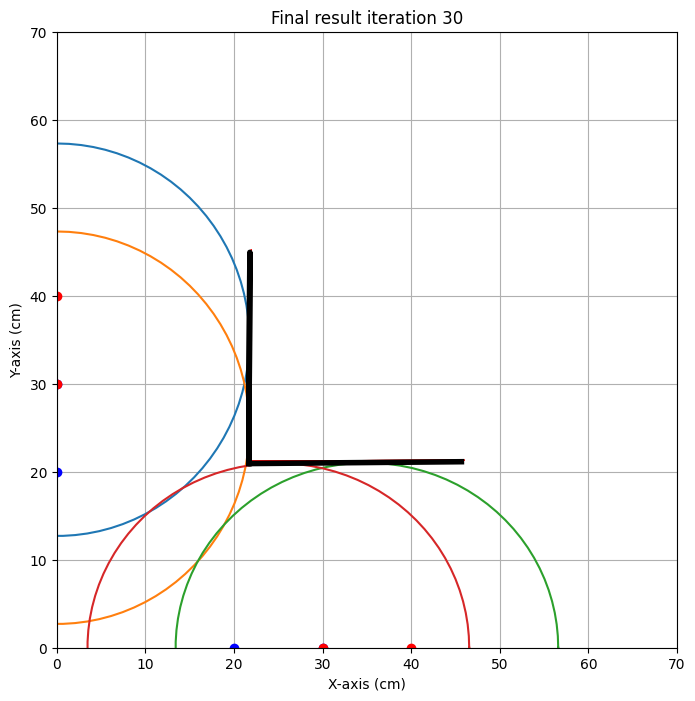

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,44.60],
    [0,30,0,20,44.60],
    #[0,10,0,20,49.7],
    [40,0,30,0,43.2],
    [30,0,20,0,43.1],
    #[10,0,20,0,51.3],
    #[10,0,0,10,18.1]hoek    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.7 cm met een standaardafwijking van 0.3 cm 
y0: 20.9 cm met een standaardafwijking van 0.3 cm 
alpha: 0.5 graden met een standaardafwijking van 0.2 graad 
beta: 0.3 graden met een standaardafwijking van 0.3 graad 



## Opdracht 5: Iteratie 0

#### algoritme [isha]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="algoritme isha.jpeg" width="400">

#### algoritme [wout]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="algortime wout.jpeg" width="400">

#### algoritme [thibo]
Voeg een foto in van het algoritme van het derde groepslid
<img src="algortime thibo.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':52,  #zelf aanvullen,
           'y0':37,
           'alpha' :0, #zelf aanvullen,
           'beta' : 25, #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'wout' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    #[0,10,0,20,119.5],
    [0,40,0,50,104],
    #[30,0,20,0,199],
    [70,0,60,0,81.2],
    [65,0,55,0,77.7],
    [60,0,50,0,77.29],
    [0,45,0,55,105],
    [0,35,0,45,105.25],
    ]),
       
       
       'isha' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    #[0,20,0,30,110],
    [0,40,0,50,105],
    [0,35,0,45,104.7],
    [0,45,0,55,105.7],
    [47,0,57,0,79.0],
    [52,0,62,0,77.26],
    #[42,0,52,0,82.9],
    ]),
      }

## Opdracht 7: Evaluatie.

wout
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0   0  40   0  50  104.00
1  70   0  60   0   81.20
2  65   0  55   0   77.70
3  60   0  50   0   77.29
4   0  45   0  55  105.00
5   0  35   0  45  105.25


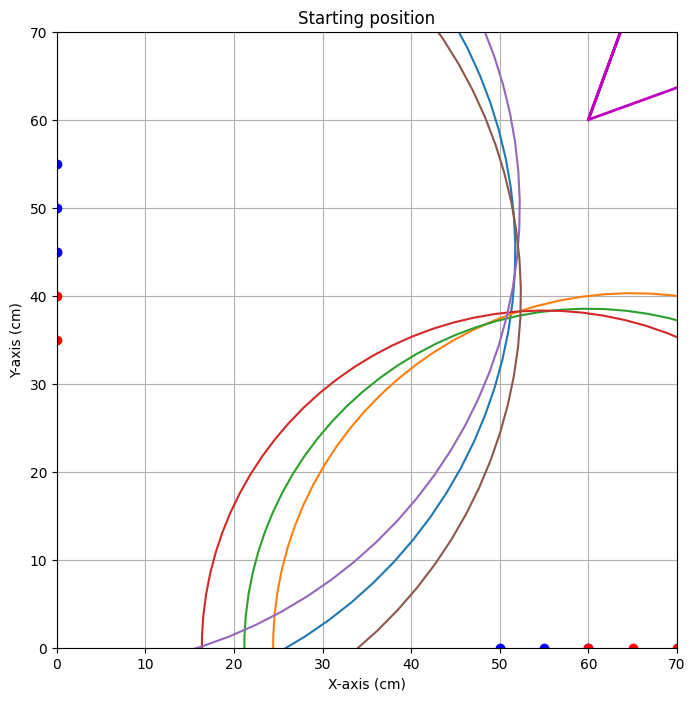


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=37.127


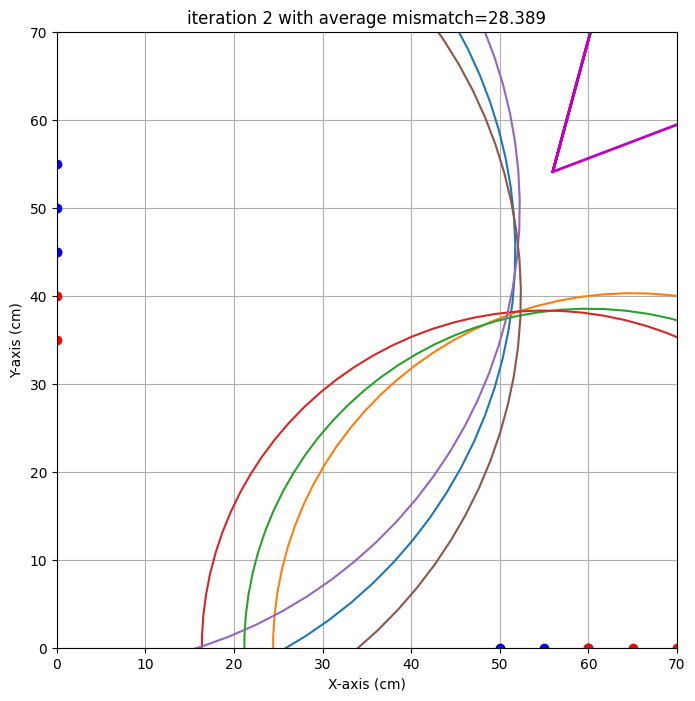

end iteration 2 with average mismatch=28.389


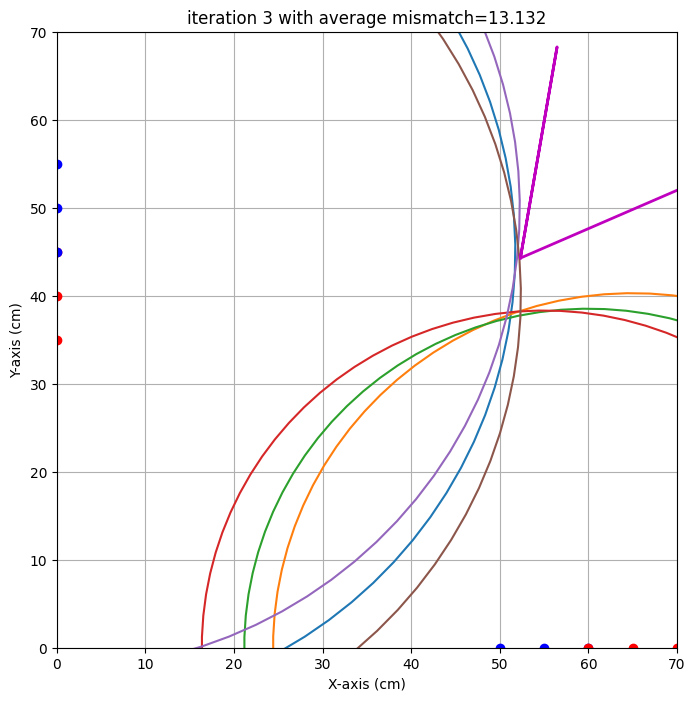

end iteration 3 with average mismatch=13.132


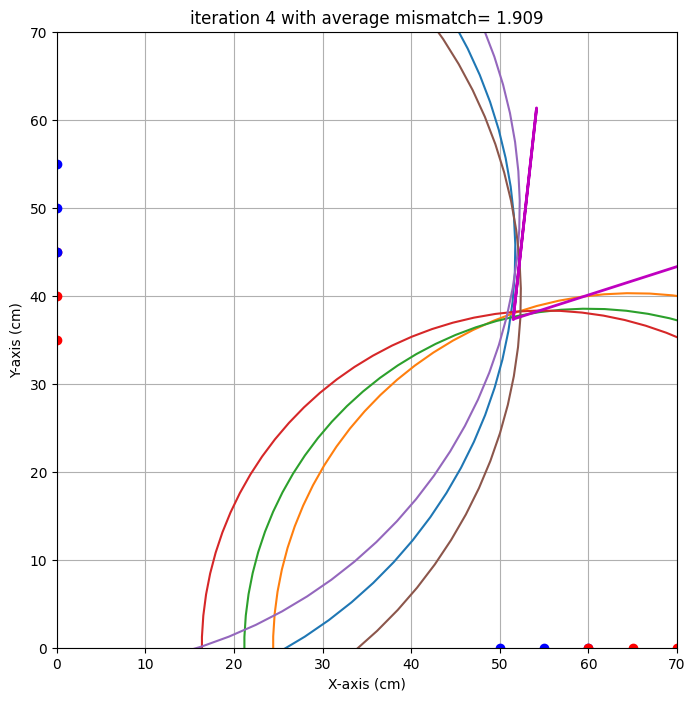

end iteration 4 with average mismatch= 1.909
end iteration 5 with average mismatch= 1.740
end iteration 6 with average mismatch= 1.740
end iteration 7 with average mismatch= 1.639


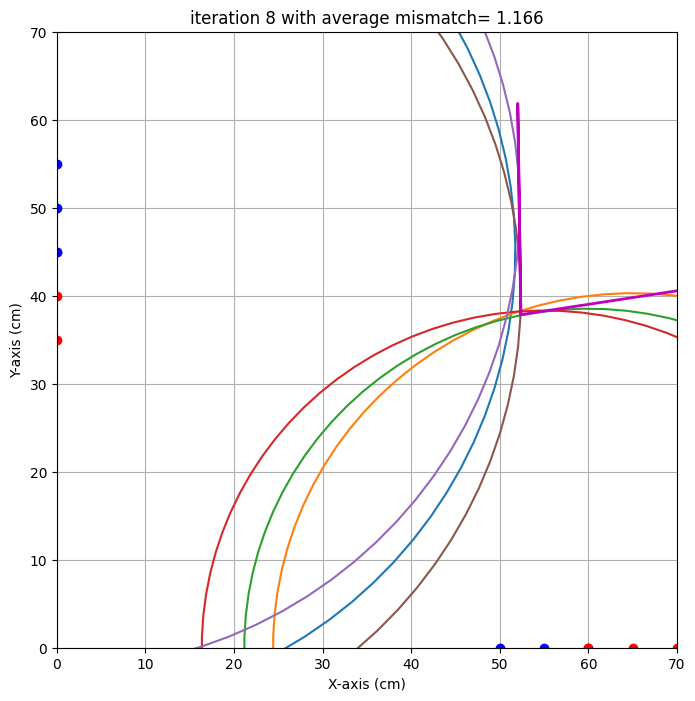

end iteration 8 with average mismatch= 1.166
end iteration 9 with average mismatch= 1.085
end iteration 10 with average mismatch= 1.012
end iteration 11 with average mismatch= 1.008
end iteration 12 with average mismatch= 1.007
end iteration 13 with average mismatch= 1.007
end iteration 14 with average mismatch= 1.007
end iteration 15 with average mismatch= 1.007
end iteration 16 with average mismatch= 1.007
end iteration 17 with average mismatch= 1.007
end iteration 18 with average mismatch= 1.007
end iteration 19 with average mismatch= 1.007
end iteration 20 with average mismatch= 1.003
end iteration 21 with average mismatch= 0.959
end iteration 22 with average mismatch= 0.957
end iteration 23 with average mismatch= 0.957
end iteration 24 with average mismatch= 0.956
end iteration 25 with average mismatch= 0.956
end iteration 26 with average mismatch= 0.956
end iteration 27 with average mismatch= 0.956
end iteration 28 with average mismatch= 0.956
end iteration 29 with average mismat

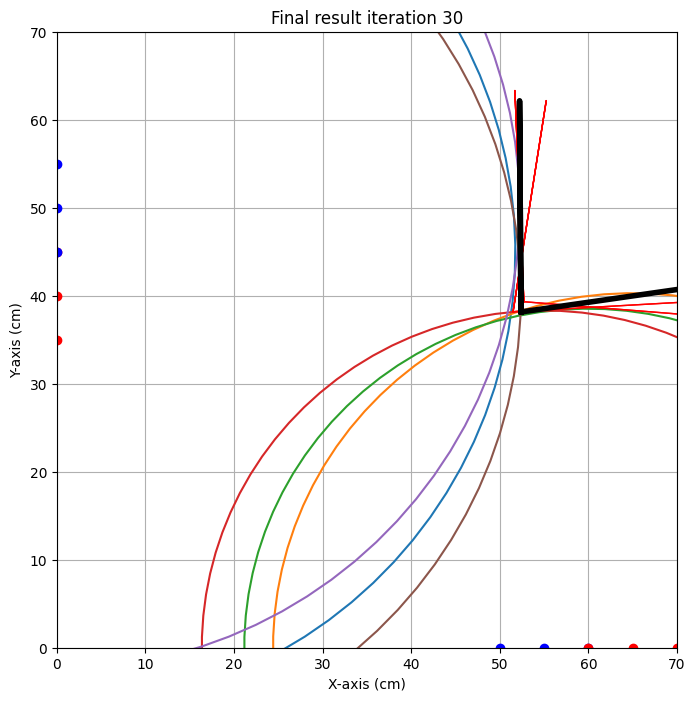

{'alpha': np.float64(8.237696520306155), 'alpha_eps': np.float64(12.83011785911281), 'beta': np.float64(-0.36808490623082374), 'beta_eps': np.float64(9.243561332154211), 'x0': np.float64(52.39010181522791), 'x0_eps': np.float64(0.8888190517774461), 'y0': np.float64(38.152303203007484), 'y0_eps': np.float64(1.165887394654618)}
isha
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0   0  40   0  50  105.00
1   0  35   0  45  104.70
2   0  45   0  55  105.70
3  47   0  57   0   79.00
4  52   0  62   0   77.26


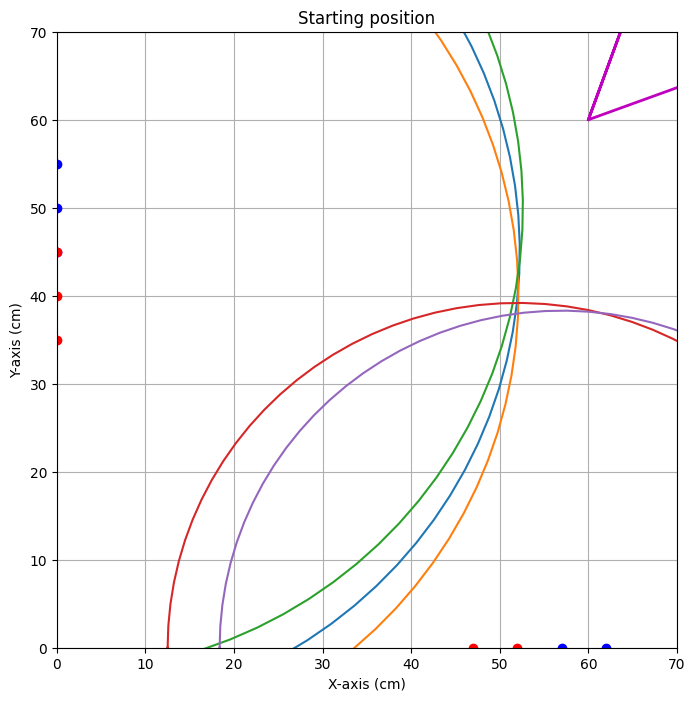


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=34.585


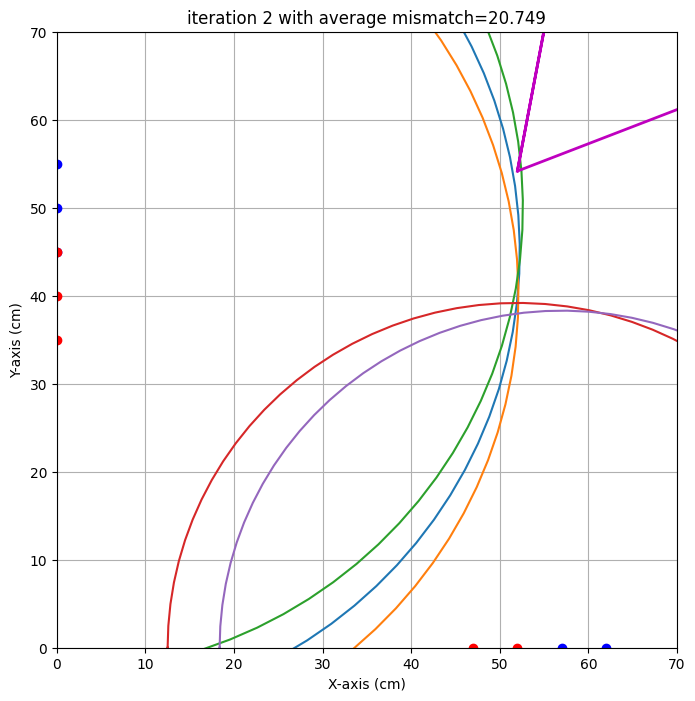

end iteration 2 with average mismatch=20.749


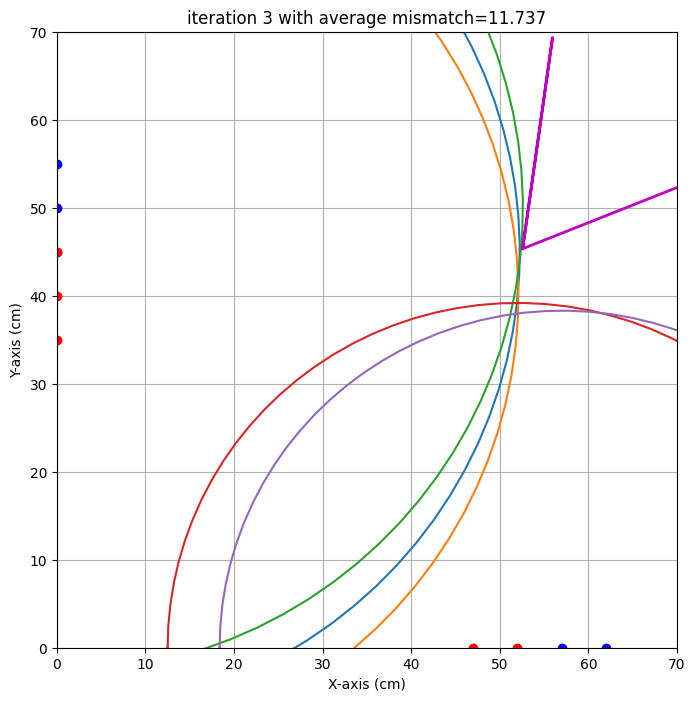

end iteration 3 with average mismatch=11.737


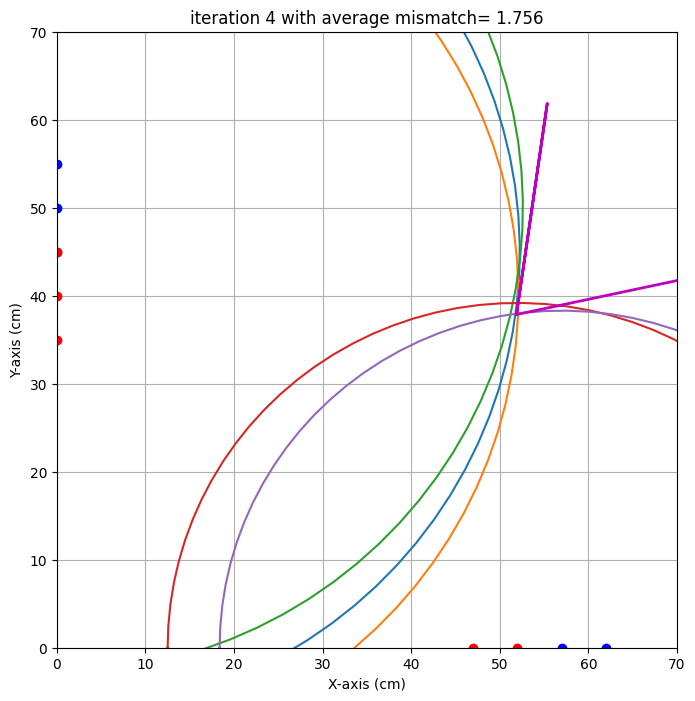

end iteration 4 with average mismatch= 1.756
end iteration 5 with average mismatch= 1.756
end iteration 6 with average mismatch= 1.683


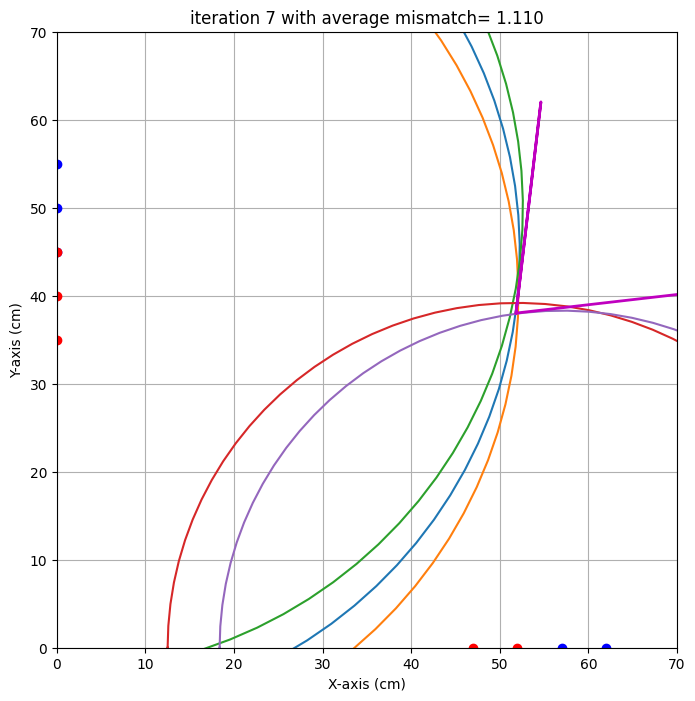

end iteration 7 with average mismatch= 1.110
end iteration 8 with average mismatch= 1.105


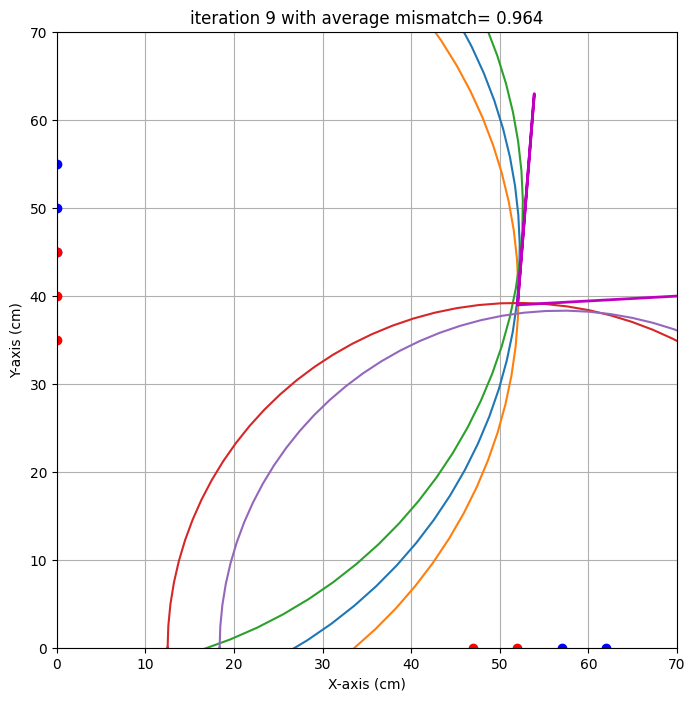

end iteration 9 with average mismatch= 0.964


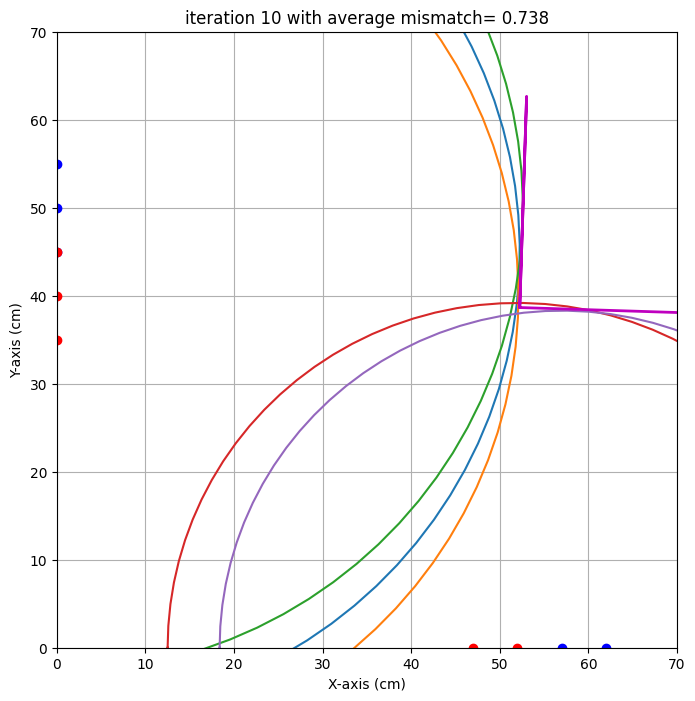

end iteration 10 with average mismatch= 0.738
end iteration 11 with average mismatch= 0.675


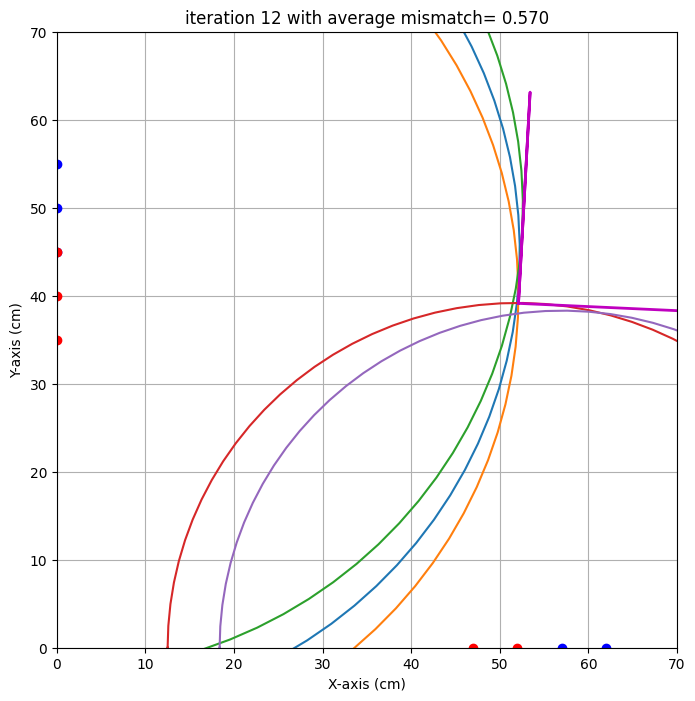

end iteration 12 with average mismatch= 0.570
end iteration 13 with average mismatch= 0.555
end iteration 14 with average mismatch= 0.507


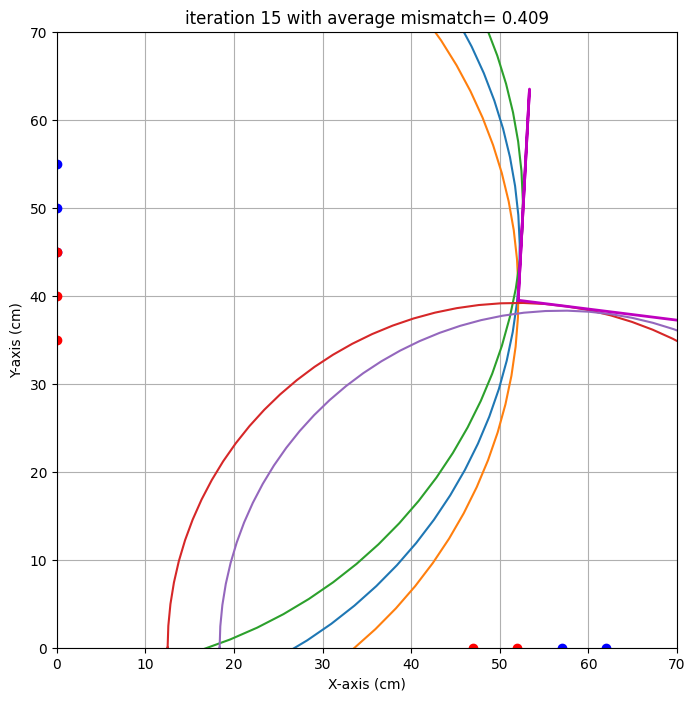

end iteration 15 with average mismatch= 0.409
end iteration 16 with average mismatch= 0.409
end iteration 17 with average mismatch= 0.409
end iteration 18 with average mismatch= 0.409
end iteration 19 with average mismatch= 0.396


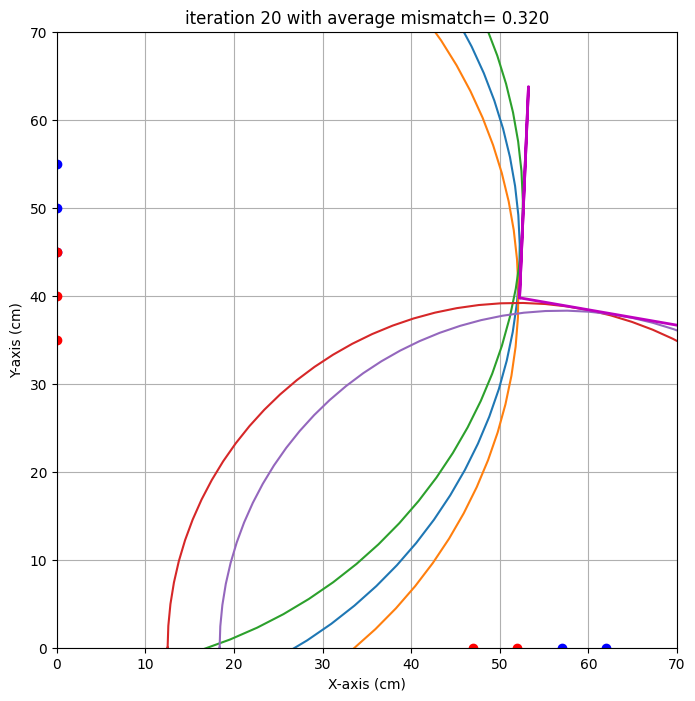

end iteration 20 with average mismatch= 0.320
end iteration 21 with average mismatch= 0.306
end iteration 22 with average mismatch= 0.306
end iteration 23 with average mismatch= 0.306
end iteration 24 with average mismatch= 0.306
end iteration 25 with average mismatch= 0.306
end iteration 26 with average mismatch= 0.306
end iteration 27 with average mismatch= 0.306
end iteration 28 with average mismatch= 0.306
end iteration 29 with average mismatch= 0.306
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.306
###############################################################################
end of iteration  30
Best alpha=  -9.92 with uncertainty=   5.96
Best beta =   2.41 with uncertainty=   4.73
Best x0   =  52.22 with uncertainty=   0.29
Best y0   =  39.75 with uncertainty=   1.45
###############################################################################


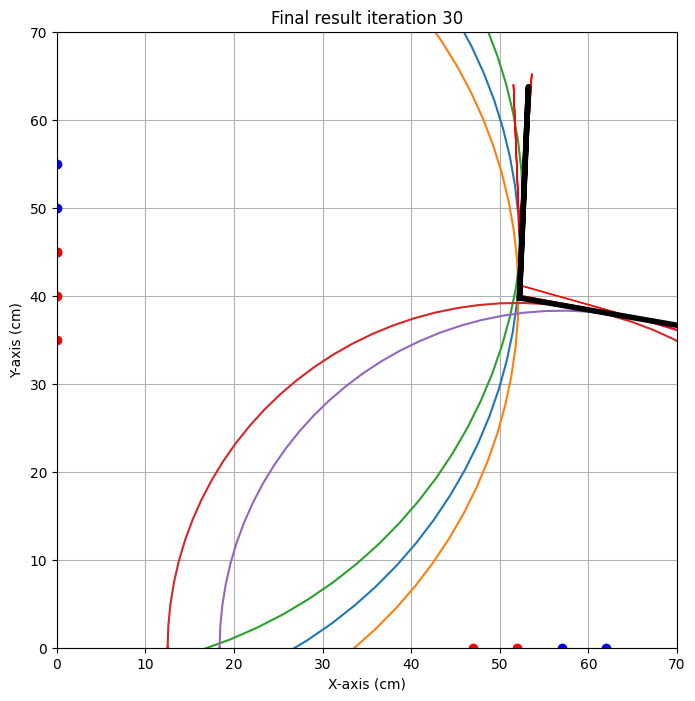

{'alpha': np.float64(-9.918108330282118), 'alpha_eps': np.float64(5.960159085942765), 'beta': np.float64(2.406394574854168), 'beta_eps': np.float64(4.728664489135936), 'x0': np.float64(52.22467436381169), 'x0_eps': np.float64(0.29374775949884935), 'y0': np.float64(39.75430067430112), 'y0_eps': np.float64(1.4464264021054163)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

wout 
x0 target is : 52.0. Gevonden waarde: 52.4 cm met een standaardafwijking van 0.9 cm 
y0 target is : 37.0. Gevonden waarde: 38.2 cm met een standaardafwijking van 1.2 cm 
alpha target is : 0.0. Gevonden waarde: 8.2 graden met een standaardafwijking van 12.8 graad 
beta target is : 25.0. Gevonden waarde: -0.4 graden met een standaardafwijking van 9.2 graad 

isha 
x0 target is : 52.0. Gevonden waarde: 52.2 cm met een standaardafwijking van 0.3 cm 
y0 target is : 37.0. Gevonden waarde: 39.8 cm met een standaardafwijking van 1.4 cm 
alpha target is : 0.0. Gevonden waarde: -9.9 graden met een standaardafwijking van 6.0 graad 
beta target is : 25.0. Gevonden waarde: 2.4 graden met een standaardafwijking van 4.7 graad 



## Opdracht 8: Iteratie1+.14:40.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](eessteiter.jpeg)
Figuur: ![Alt](tweedeiter.jpeg)
Figuur: ![Alt](derdeiter.jpeg)
Figuur: ![Alt](4iter.jpeg)

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  20   0  30   0  70.67
1  30   0  40   0  70.70
2  40   0  50   0  71.20
3   0  30   0  40  51.50
4   0  40   0  50  51.90
5   0  50   0  60  54.50


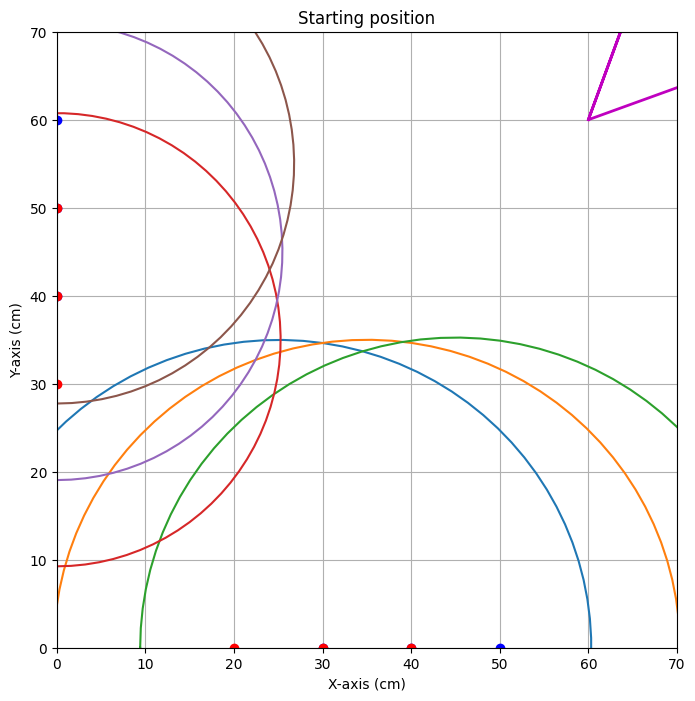


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=72.740


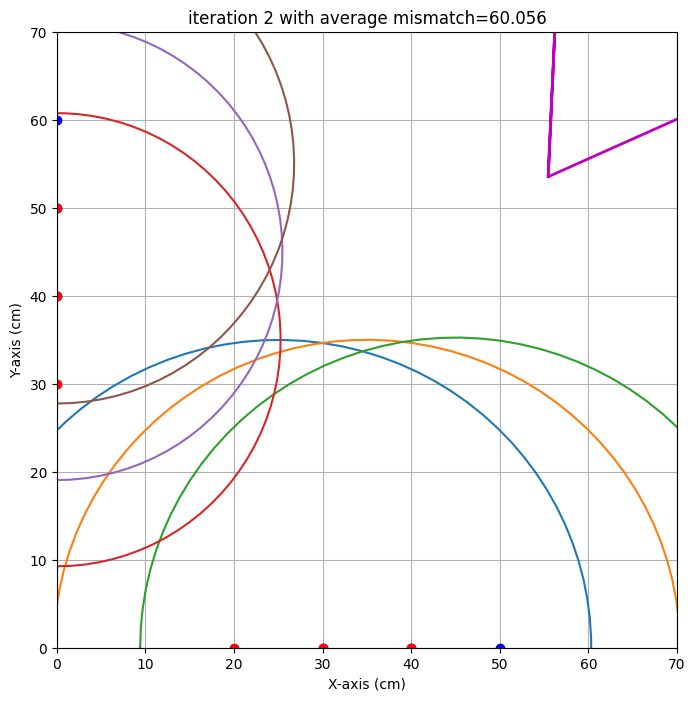

end iteration 2 with average mismatch=60.056


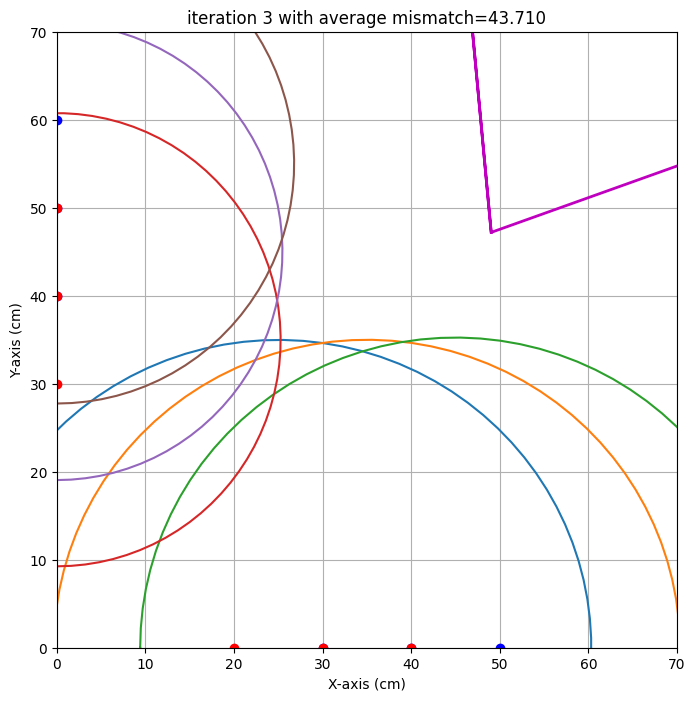

end iteration 3 with average mismatch=43.710


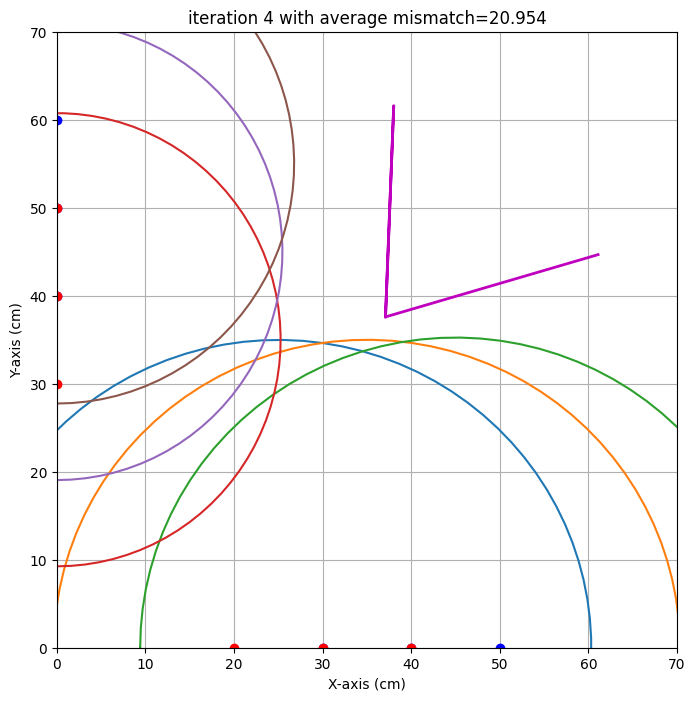

end iteration 4 with average mismatch=20.954


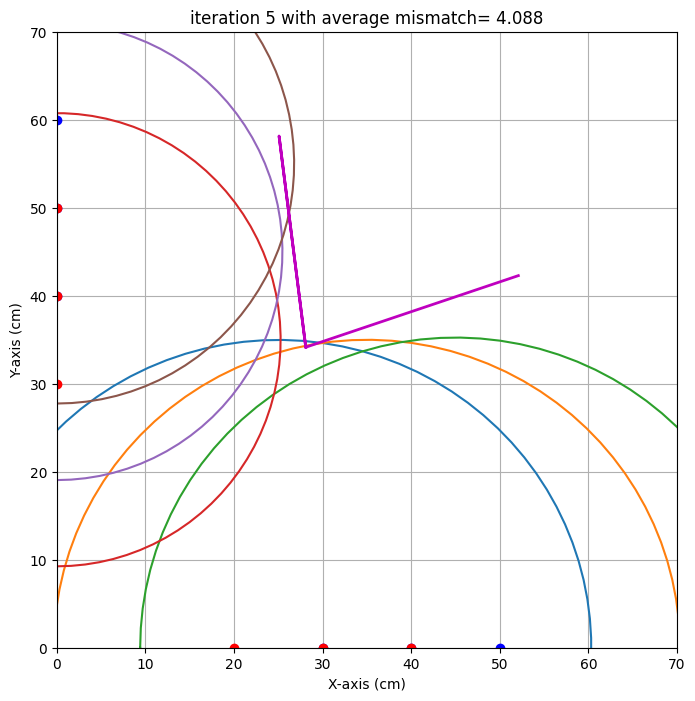

end iteration 5 with average mismatch= 4.088


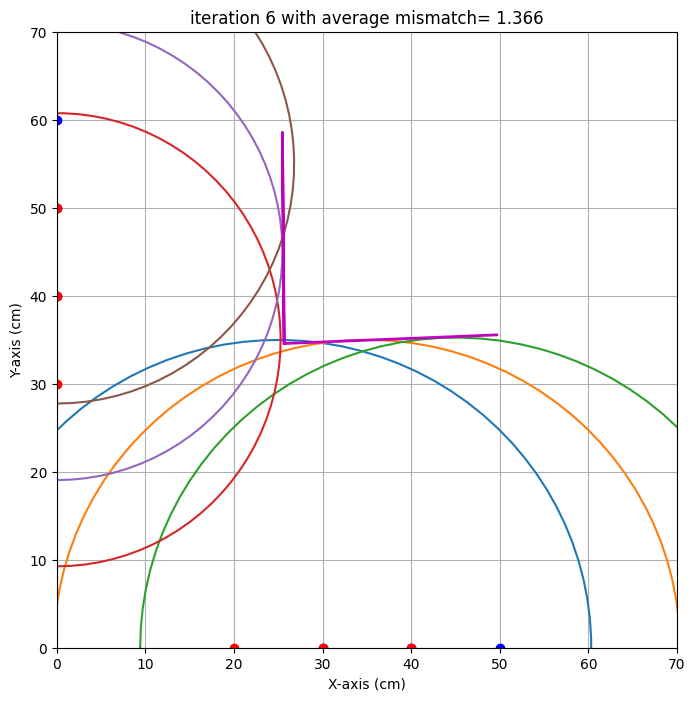

end iteration 6 with average mismatch= 1.366


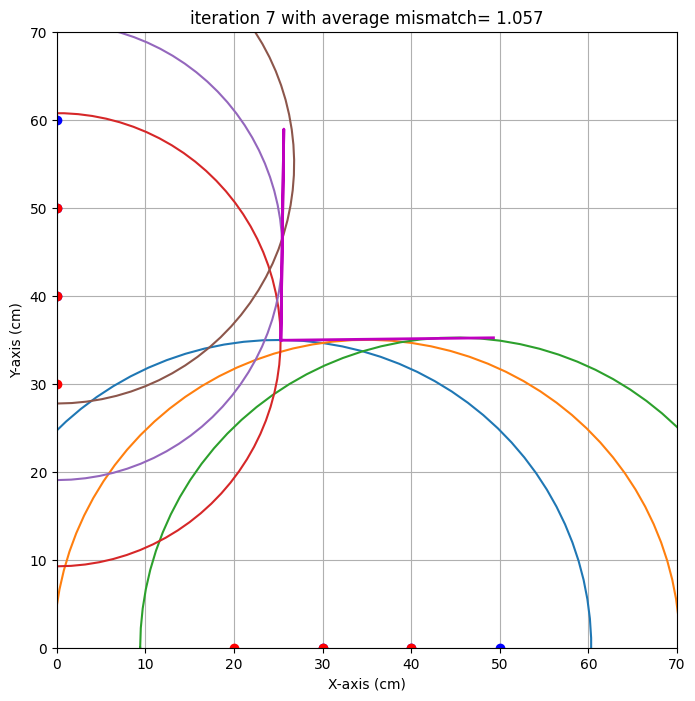

end iteration 7 with average mismatch= 1.057
end iteration 8 with average mismatch= 1.033


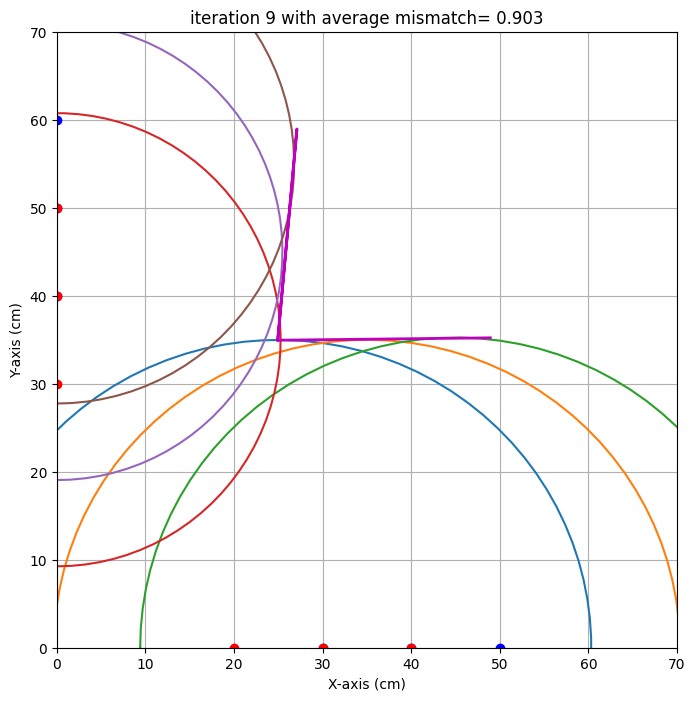

end iteration 9 with average mismatch= 0.903
end iteration 10 with average mismatch= 0.903
end iteration 11 with average mismatch= 0.903


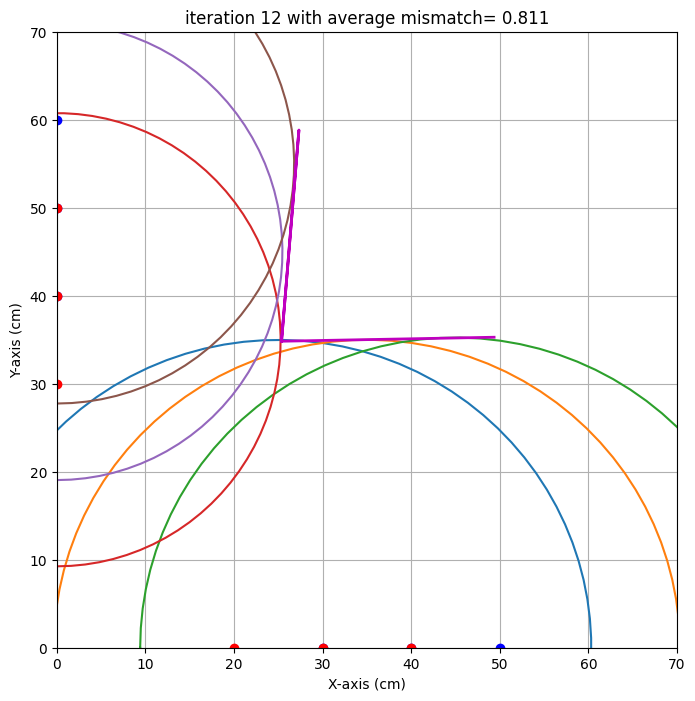

end iteration 12 with average mismatch= 0.811


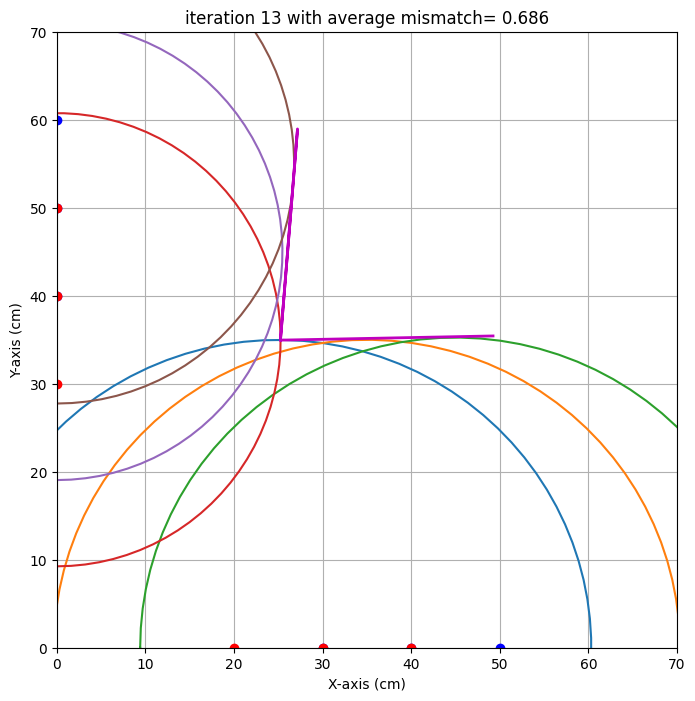

end iteration 13 with average mismatch= 0.686
end iteration 14 with average mismatch= 0.664
end iteration 15 with average mismatch= 0.662
end iteration 16 with average mismatch= 0.662
end iteration 17 with average mismatch= 0.662
end iteration 18 with average mismatch= 0.662
end iteration 19 with average mismatch= 0.662
end iteration 20 with average mismatch= 0.662
end iteration 21 with average mismatch= 0.662
end iteration 22 with average mismatch= 0.662
end iteration 23 with average mismatch= 0.662
end iteration 24 with average mismatch= 0.662
end iteration 25 with average mismatch= 0.662
end iteration 26 with average mismatch= 0.662
end iteration 27 with average mismatch= 0.662
end iteration 28 with average mismatch= 0.662
end iteration 29 with average mismatch= 0.662
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.662
###############################################################

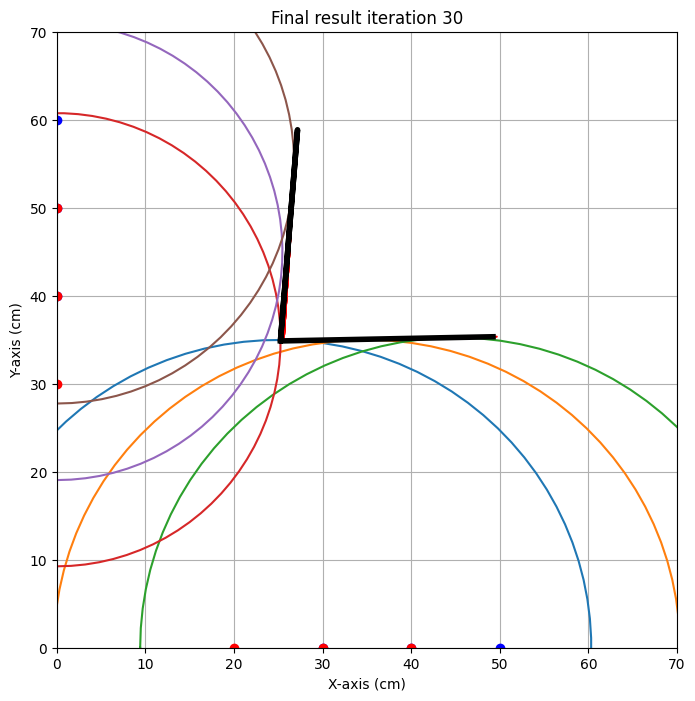

{'alpha': np.float64(1.1335687379829011), 'alpha_eps': np.float64(0.11820193369734477), 'beta': np.float64(4.596380511525691), 'beta_eps': np.float64(0.9064445789058864), 'x0': np.float64(25.23793100613294), 'x0_eps': np.float64(0.40038546694362154), 'y0': np.float64(34.861925803984164), 'y0_eps': np.float64(0.06661685529526551)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  20   0  30   0  42.76
1  30   0  40   0  42.28
2  40   0  50   0  44.00
3   0  20   0  30  47.40
4   0  30   0  40  44.80
5   0  40   0  50  48.60


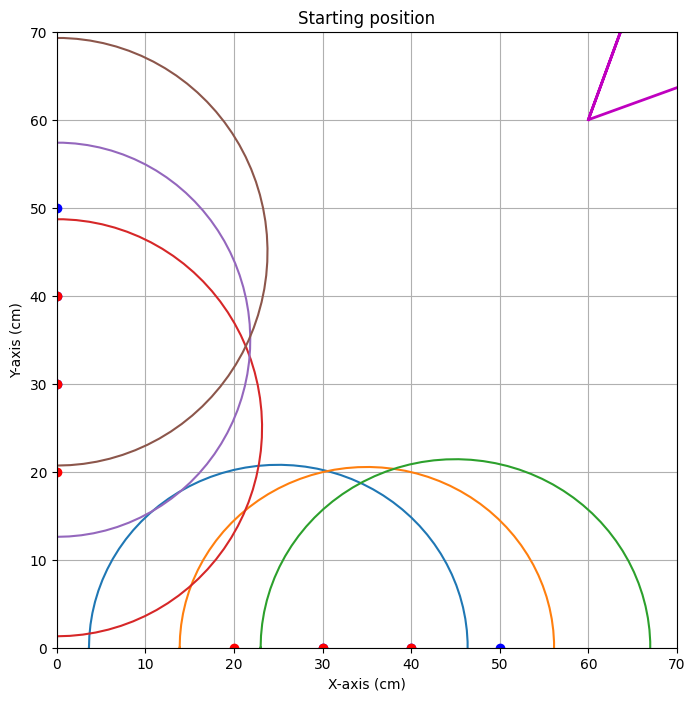


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=93.185


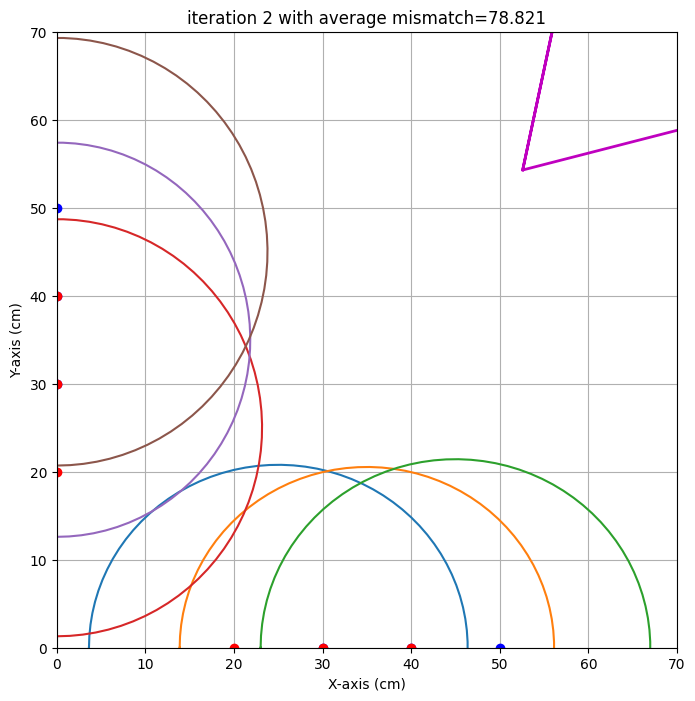

end iteration 2 with average mismatch=78.821


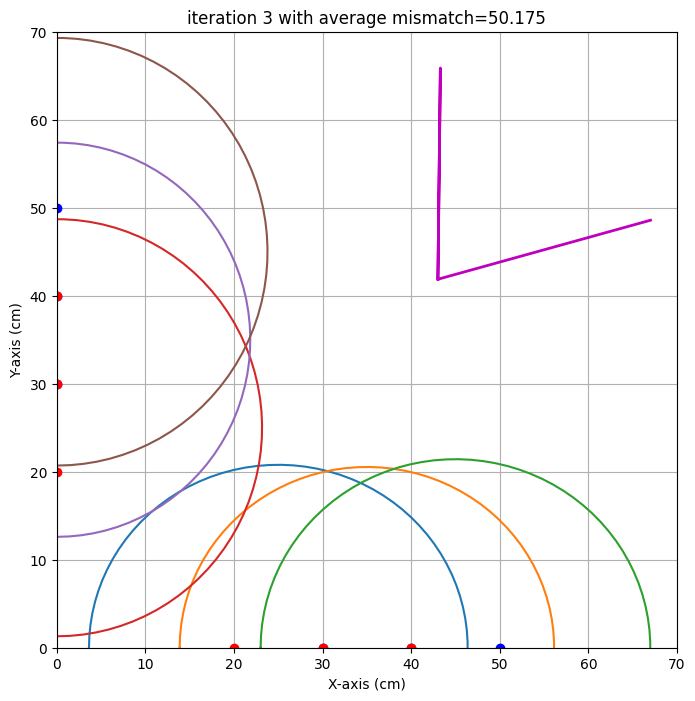

end iteration 3 with average mismatch=50.175


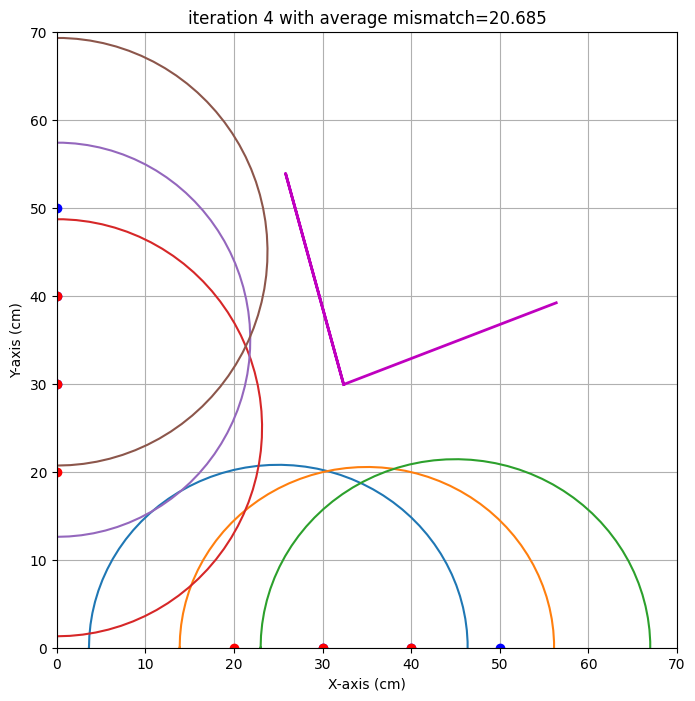

end iteration 4 with average mismatch=20.685


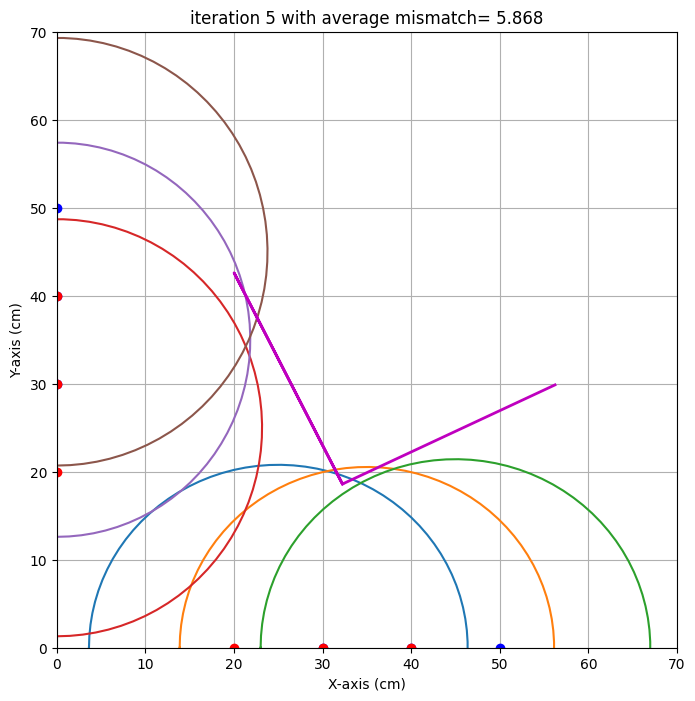

end iteration 5 with average mismatch= 5.868


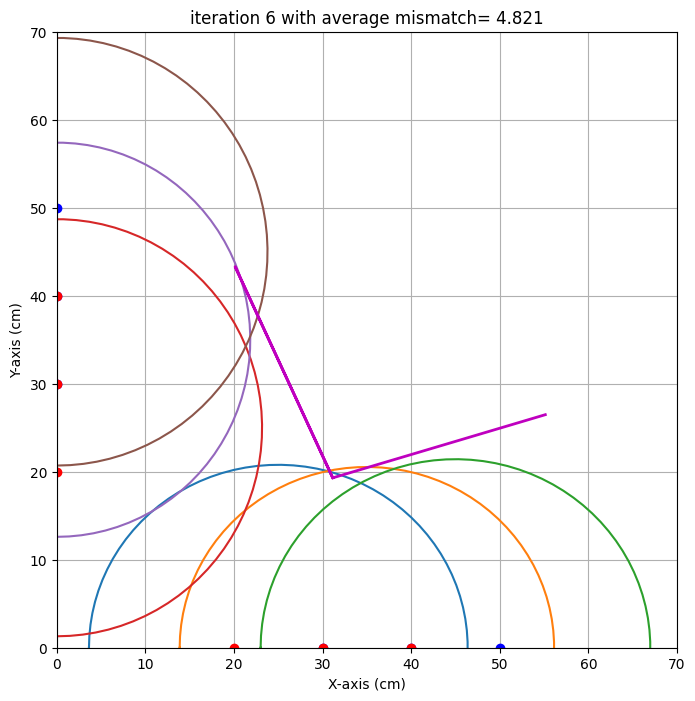

end iteration 6 with average mismatch= 4.821


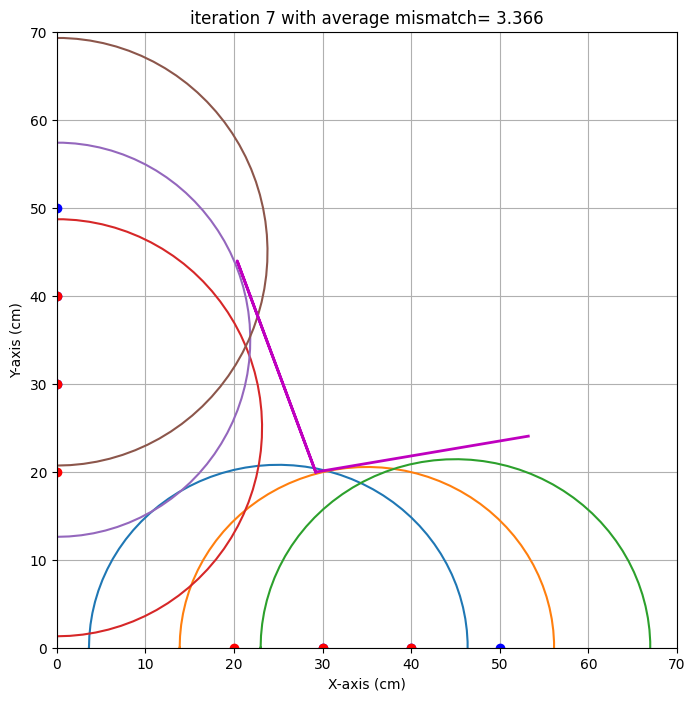

end iteration 7 with average mismatch= 3.366


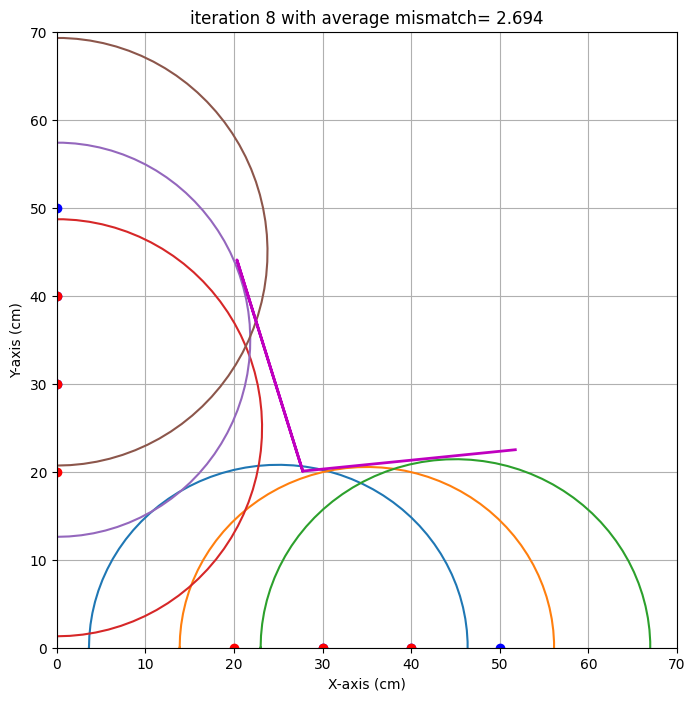

end iteration 8 with average mismatch= 2.694
end iteration 9 with average mismatch= 2.478


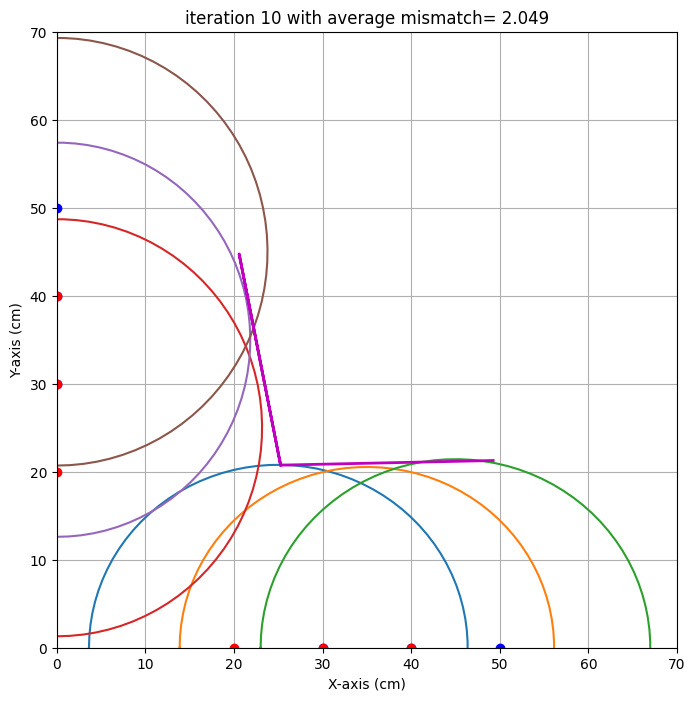

end iteration 10 with average mismatch= 2.049


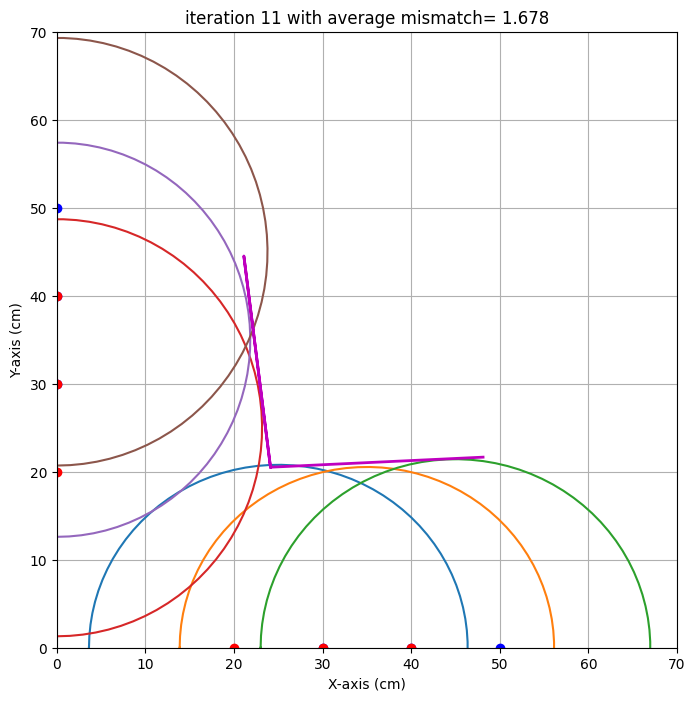

end iteration 11 with average mismatch= 1.678


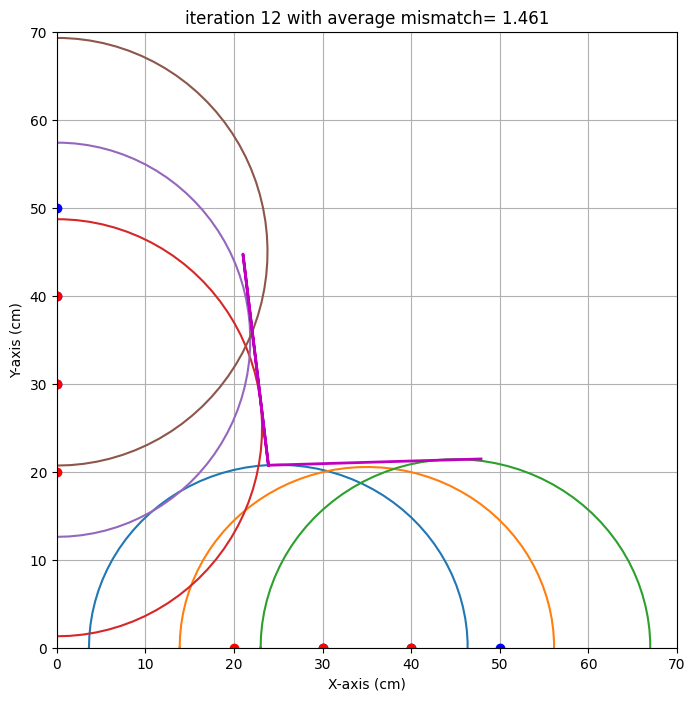

end iteration 12 with average mismatch= 1.461
end iteration 13 with average mismatch= 1.461
end iteration 14 with average mismatch= 1.461
end iteration 15 with average mismatch= 1.461
end iteration 16 with average mismatch= 1.461
end iteration 17 with average mismatch= 1.461
end iteration 18 with average mismatch= 1.461
end iteration 19 with average mismatch= 1.461
end iteration 20 with average mismatch= 1.456
end iteration 21 with average mismatch= 1.443
end iteration 22 with average mismatch= 1.422
end iteration 23 with average mismatch= 1.374
end iteration 24 with average mismatch= 1.374
end iteration 25 with average mismatch= 1.374
end iteration 26 with average mismatch= 1.374
end iteration 27 with average mismatch= 1.374
end iteration 28 with average mismatch= 1.374
end iteration 29 with average mismatch= 1.374
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 1.374
#################

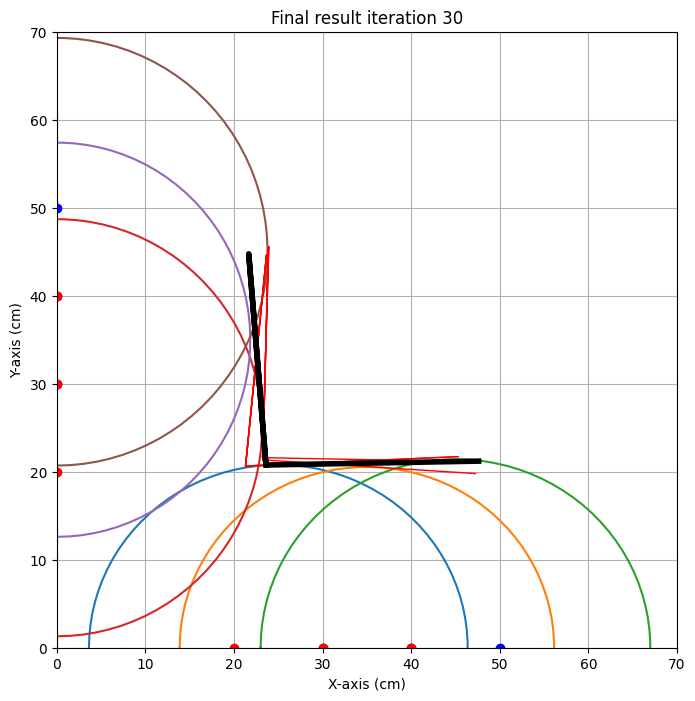

{'alpha': np.float64(1.0490070294474805), 'alpha_eps': np.float64(4.7541315977172065), 'beta': np.float64(-4.6563972980730535), 'beta_eps': np.float64(10.290315296135955), 'x0': np.float64(23.60976079831253), 'x0_eps': np.float64(2.3101548513597407), 'y0': np.float64(20.763566717343785), 'y0_eps': np.float64(0.8332096402159124)}
locatie 3
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  30   0  40  91.2
1   0  40   0  50  90.6
2   0  50   0  60  93.0
3  50   0  60   0  79.6
4  55   0  65   0  82.5
5  60   0  70   0  84.3


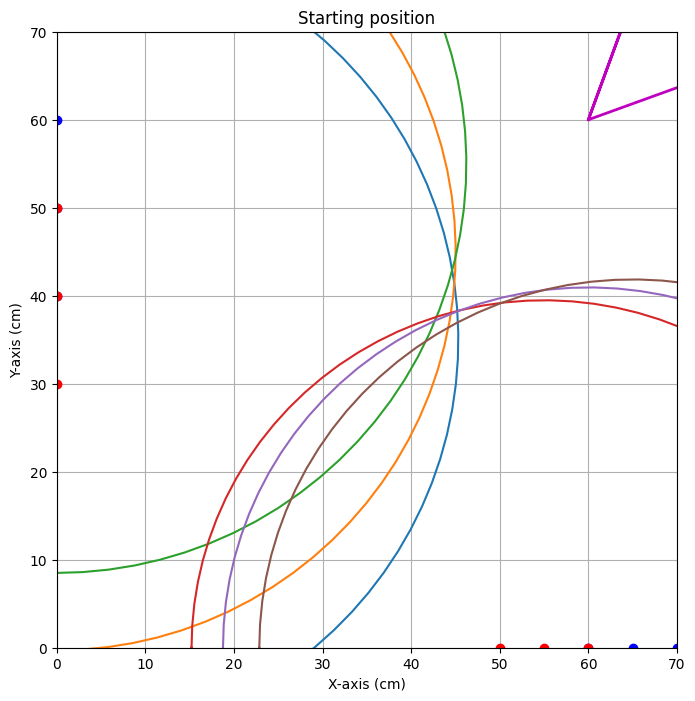


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=42.352


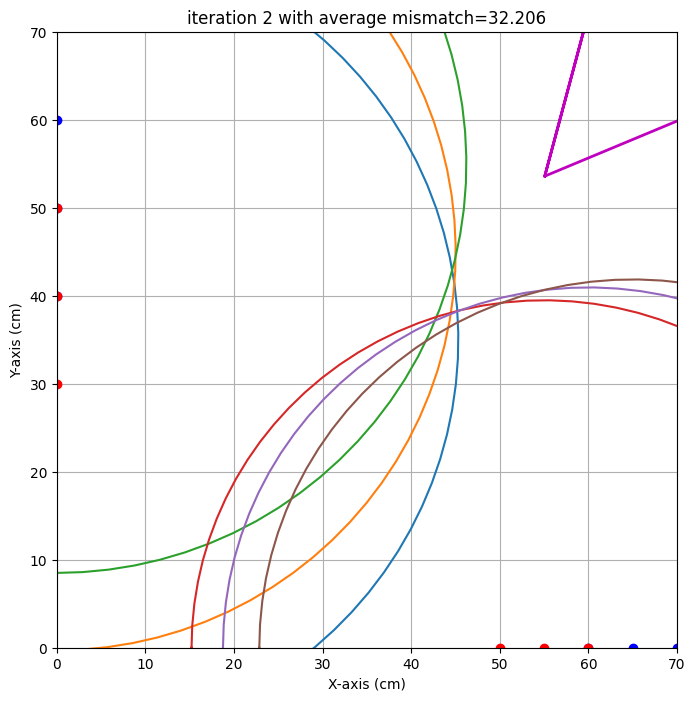

end iteration 2 with average mismatch=32.206


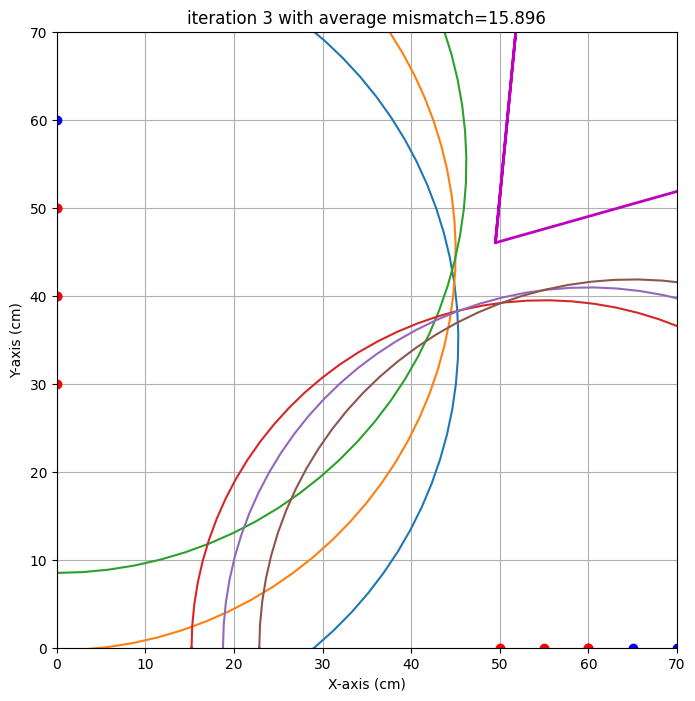

end iteration 3 with average mismatch=15.896


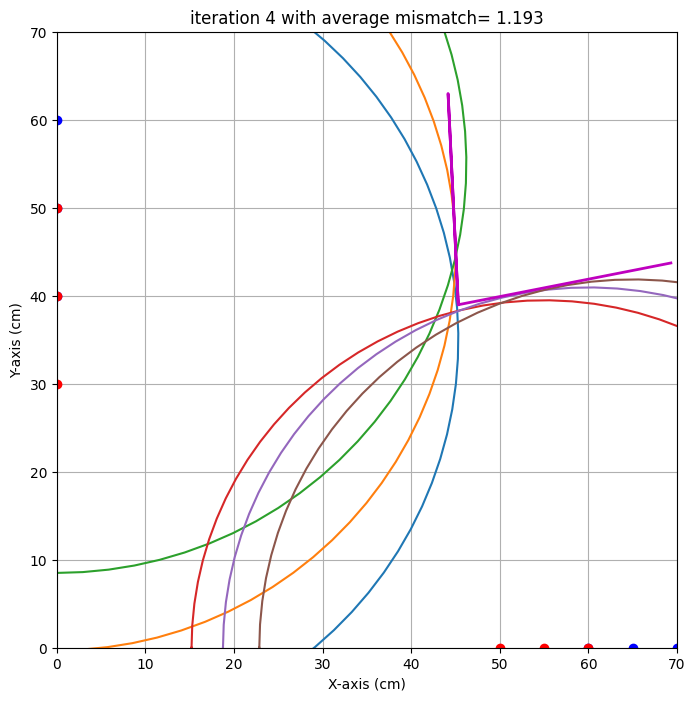

end iteration 4 with average mismatch= 1.193


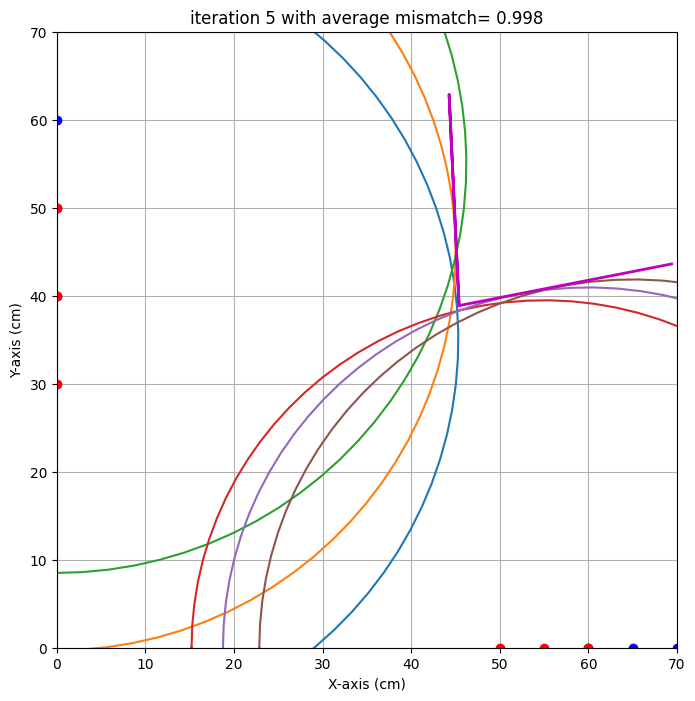

end iteration 5 with average mismatch= 0.998
end iteration 6 with average mismatch= 0.976
end iteration 7 with average mismatch= 0.974
end iteration 8 with average mismatch= 0.973
end iteration 9 with average mismatch= 0.973
end iteration 10 with average mismatch= 0.968
end iteration 11 with average mismatch= 0.897
end iteration 12 with average mismatch= 0.883
end iteration 13 with average mismatch= 0.856
end iteration 14 with average mismatch= 0.830
end iteration 15 with average mismatch= 0.820
end iteration 16 with average mismatch= 0.817
end iteration 17 with average mismatch= 0.816
end iteration 18 with average mismatch= 0.816
end iteration 19 with average mismatch= 0.815
end iteration 20 with average mismatch= 0.782
end iteration 21 with average mismatch= 0.774
end iteration 22 with average mismatch= 0.762
end iteration 23 with average mismatch= 0.762
end iteration 24 with average mismatch= 0.762
end iteration 25 with average mismatch= 0.762
end iteration 26 with average mismatch=

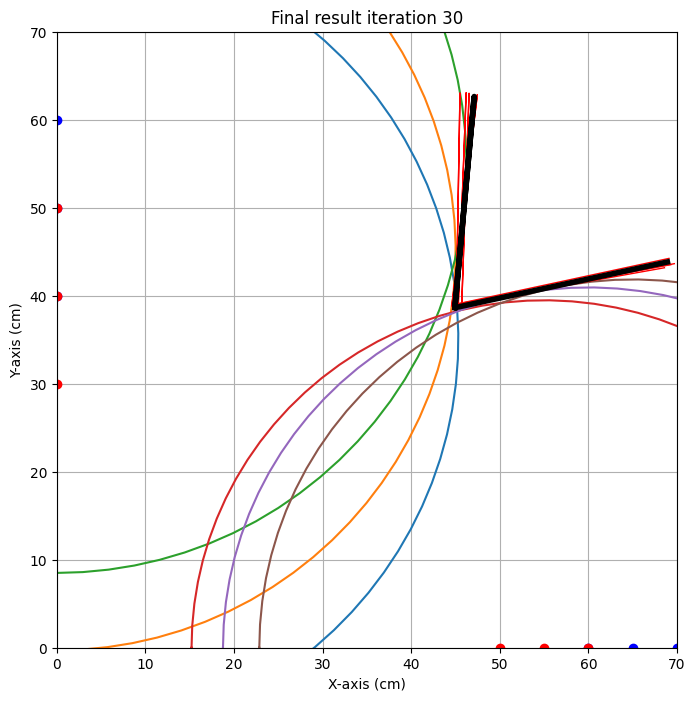

{'alpha': np.float64(12.217178628965076), 'alpha_eps': np.float64(2.0035372757143772), 'beta': np.float64(5.196646825767846), 'beta_eps': np.float64(4.224334065280882), 'x0': np.float64(44.93112872293123), 'x0_eps': np.float64(0.7772371393280011), 'y0': np.float64(38.6368173160293), 'y0_eps': np.float64(0.44627861104986266)}
locatie 1 
x0 target is : 34.6. Gevonden waarde: 25.2 cm met een standaardafwijking van 0.4 cm 
y0 target is : 25.0. Gevonden waarde: 34.9 cm met een standaardafwijking van 0.1 cm 
alpha target is : 0.0. Gevonden waarde: 1.1 graden met een standaardafwijking van 0.1 graad 
beta target is : 4.0. Gevonden waarde: 4.6 graden met een standaardafwijking van 0.9 graad 

locatie 2 
x0 target is : 20.0. Gevonden waarde: 23.6 cm met een standaardafwijking van 2.3 cm 
y0 target is : 25.0. Gevonden waarde: 20.8 cm met een standaardafwijking van 0.8 cm 
alpha target is : 0.0. Gevonden waarde: 1.0 graden met een standaardafwijking van 4.8 graad 
beta target is : 10.0. Gevonden 

In [10]:
# Voeg hier je meetgegevens van deze iteratie in:
#________________locatie 1 is iteratie 1 locatie 2 is iteratie 2 .etc_______________________


# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':34.6,#zelf aanvullen,
                    'y0':25, #zelf aanvullen,
                    'alpha' :0, #zelf aanvullen,
                    'beta' :4, #zelf aanvullen}, 
},
           'locatie 2':{'x0':20,#zelf aanvullen,
                    'y0':25, #zelf aanvullen,
                    'alpha' :0, #zelf aanvullen,
                    'beta' :10, #zelf aanvullen
},
            'locatie 3':{
                    'x0': 44,  # zelf aanvullen,
                    'y0': 37,  # zelf aanvullen,
                    'alpha' :10,  # zelf aanvullen,
                    'beta' :11,  # zelf aanvullen
            }}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    [20,0,30,0,70.67],
    [30,0,40,0,70.7],
    [40,0,50,0,71.2],
    #[50,0,60,0,76.6],
    #[0,20,0,30,0],
    [0,30,0,40,51.5],
    [0,40,0,50,51.9],
    [0,50,0,60,54.5],
    
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [20,0,30,0,42.76],
    [30,0,40,0,42.28],
    [40,0,50,0,44.0],
    #[50,0,60,0,51.4],
    [0,20,0,30,47.40],
    [0,30,0,40,44.80],
    [0,40,0,50,48.6]
    #[0,50,0,60,0],
    ]),
       'locatie 3' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,30,0,40,91.2],
    [0,40,0,50,90.6],
    [0,50,0,60,93.0],
    [50,0,60,0,79.6],
    [55,0,65,0,82.5],
    [60,0,70,0,84.3],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  30   0  40  91.08
1   0  50   0  60  89.20
2  50   0  60   0  66.52
3  55   0  65   0  67.06
4  60   0  70   0  68.49


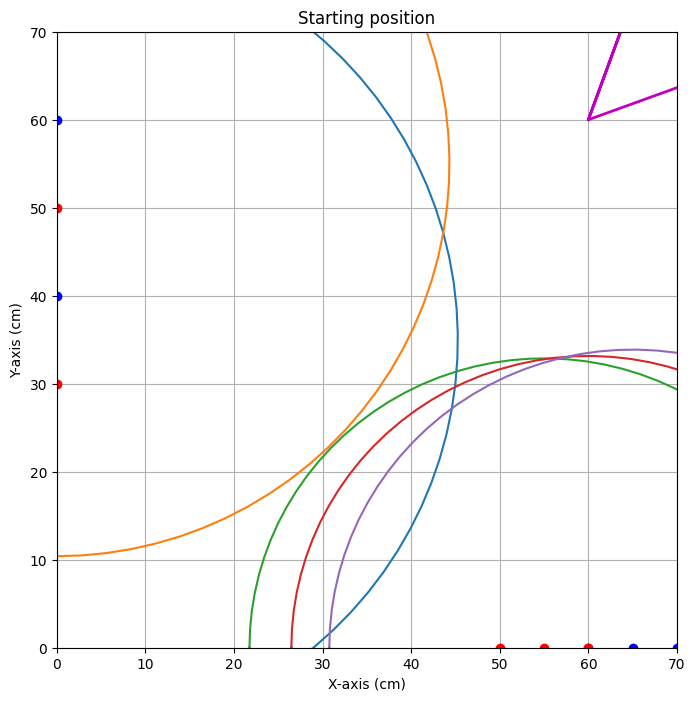


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=52.936


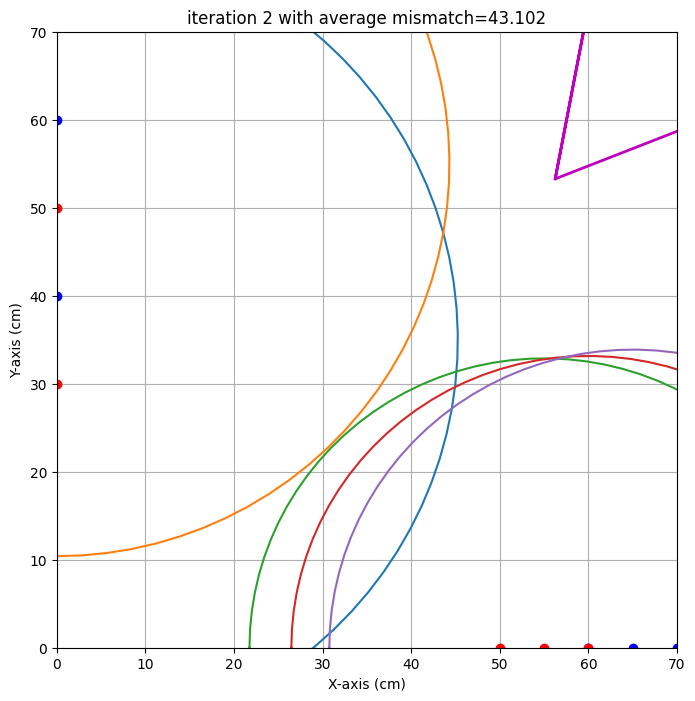

end iteration 2 with average mismatch=43.102


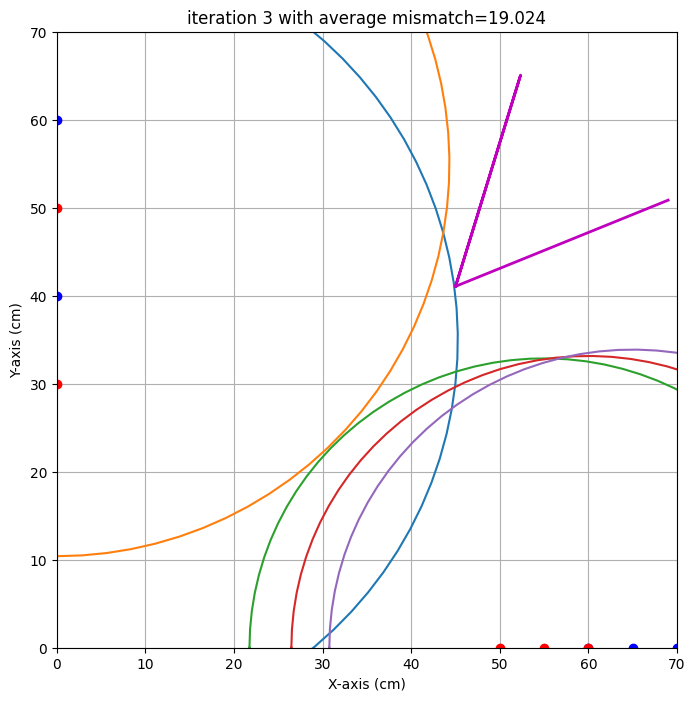

end iteration 3 with average mismatch=19.024


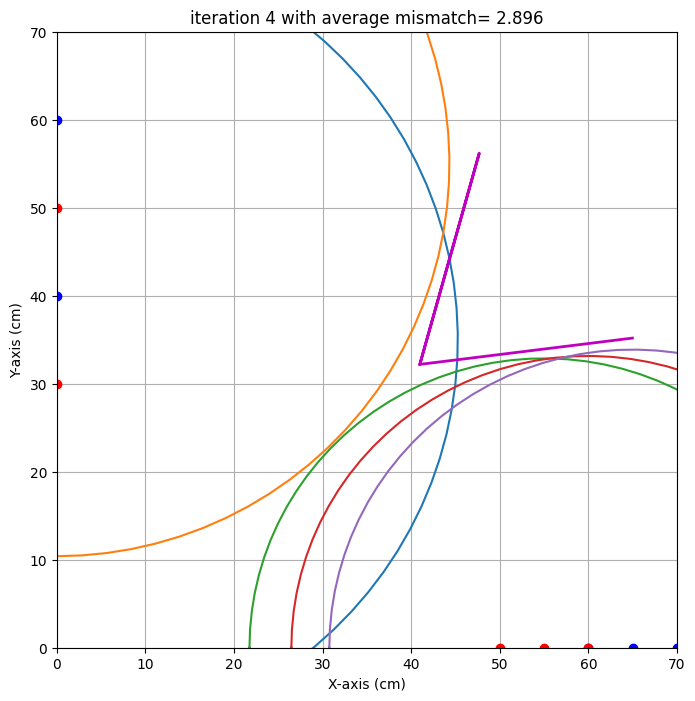

end iteration 4 with average mismatch= 2.896


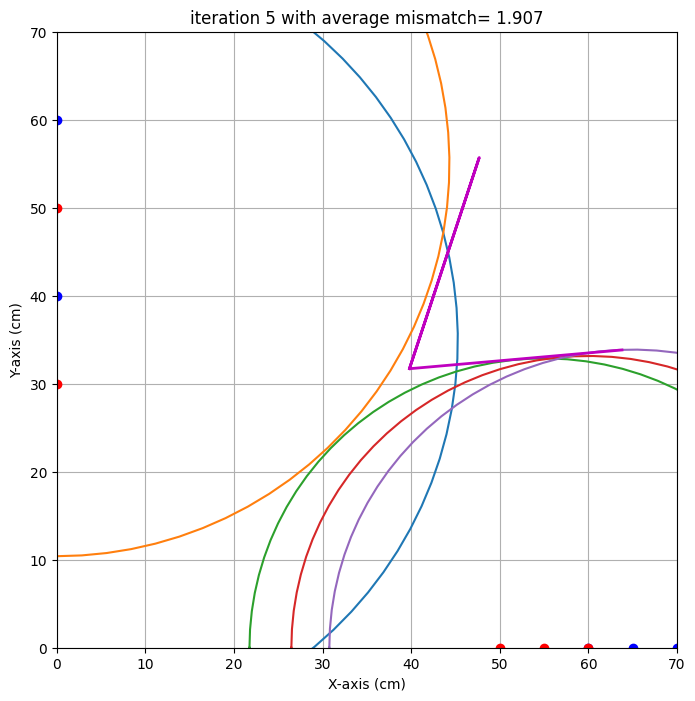

end iteration 5 with average mismatch= 1.907
end iteration 6 with average mismatch= 1.774


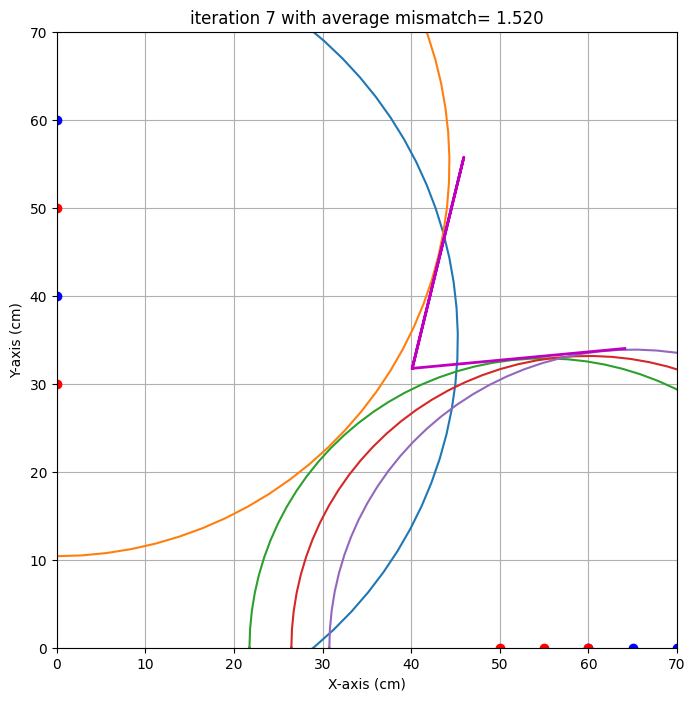

end iteration 7 with average mismatch= 1.520
end iteration 8 with average mismatch= 1.471
end iteration 9 with average mismatch= 1.452
end iteration 10 with average mismatch= 1.435
end iteration 11 with average mismatch= 1.355
end iteration 12 with average mismatch= 1.323
end iteration 13 with average mismatch= 1.290


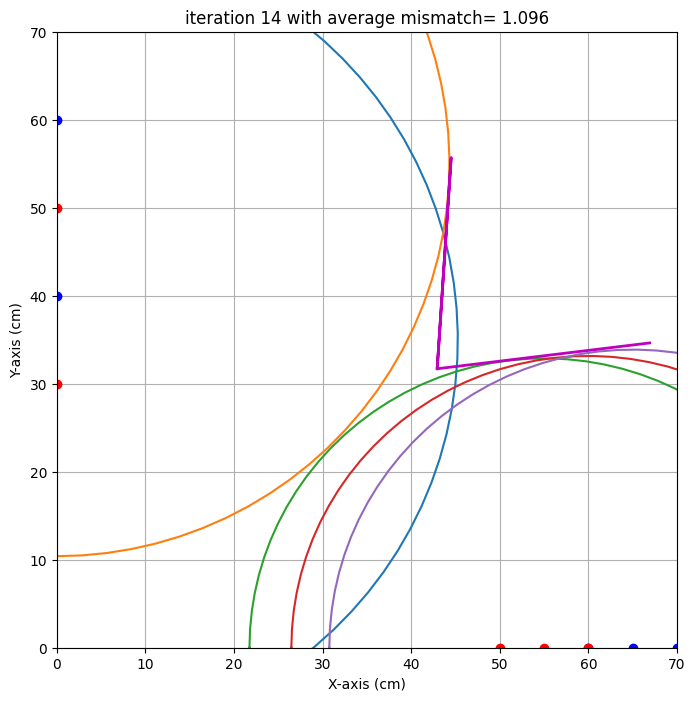

end iteration 14 with average mismatch= 1.096


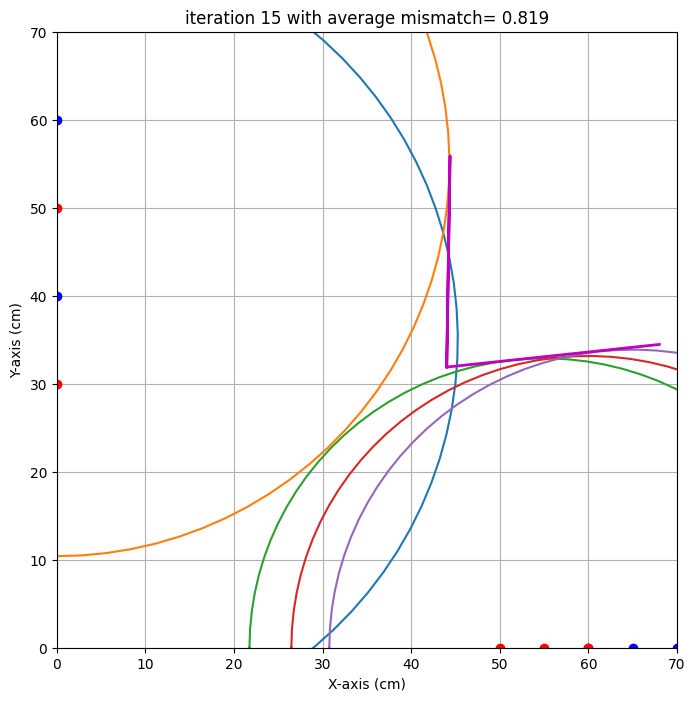

end iteration 15 with average mismatch= 0.819
end iteration 16 with average mismatch= 0.806
end iteration 17 with average mismatch= 0.806
end iteration 18 with average mismatch= 0.806
end iteration 19 with average mismatch= 0.806


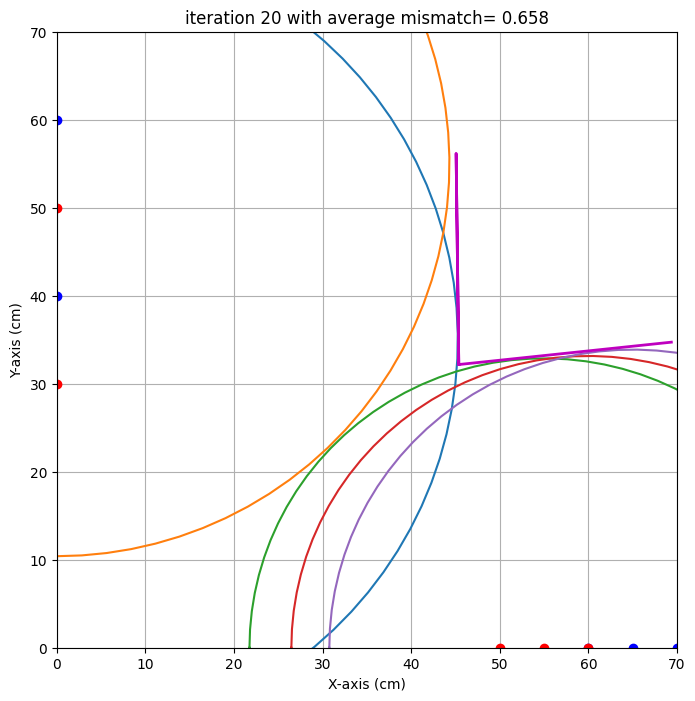

end iteration 20 with average mismatch= 0.658


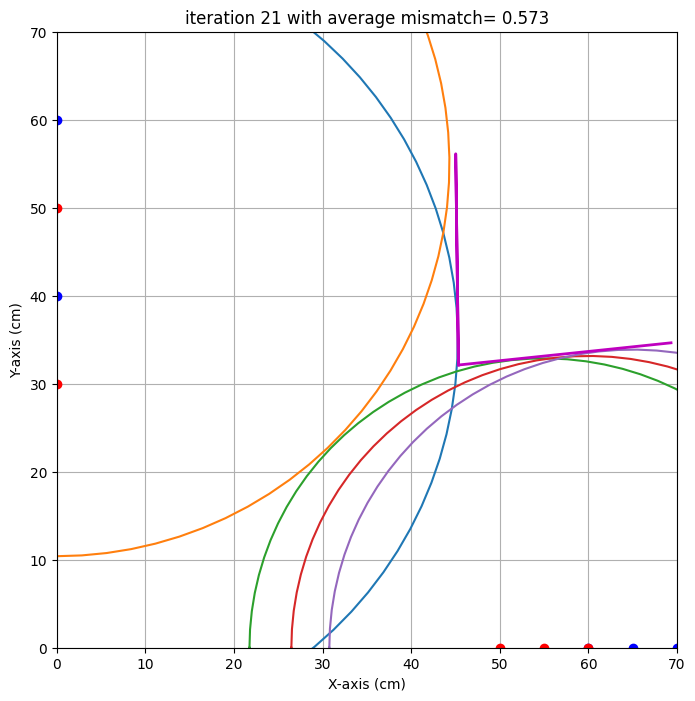

end iteration 21 with average mismatch= 0.573
end iteration 22 with average mismatch= 0.530
end iteration 23 with average mismatch= 0.524
end iteration 24 with average mismatch= 0.523
end iteration 25 with average mismatch= 0.522
end iteration 26 with average mismatch= 0.522
end iteration 27 with average mismatch= 0.516
end iteration 28 with average mismatch= 0.514
end iteration 29 with average mismatch= 0.514
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.514
###############################################################################
end of iteration  30
Best alpha=   6.42 with uncertainty=   0.49
Best beta =  -2.08 with uncertainty=   4.04
Best x0   =  45.14 with uncertainty=   0.72
Best y0   =  31.97 with uncertainty=   0.14
###############################################################################


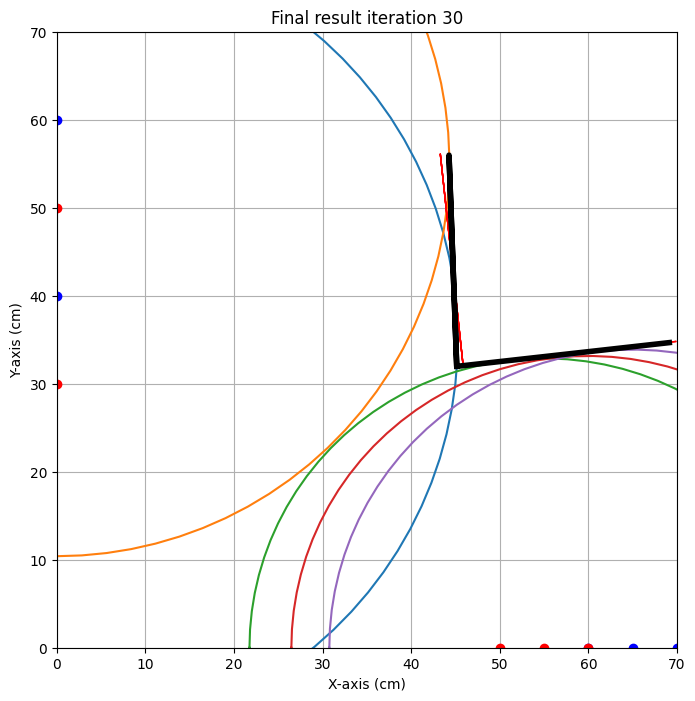

{'alpha': np.float64(6.418813244440324), 'alpha_eps': np.float64(0.4852944868288187), 'beta': np.float64(-2.0787249532051377), 'beta_eps': np.float64(4.037343855585574), 'x0': np.float64(45.14094277809356), 'x0_eps': np.float64(0.7174184362710818), 'y0': np.float64(31.970935632481478), 'y0_eps': np.float64(0.1391134693854852)}
test locatie 
x0 target is : 45.8. Gevonden waarde: 45.1 cm met een standaardafwijking van 0.7 cm 
y0 target is : 31.7. Gevonden waarde: 32.0 cm met een standaardafwijking van 0.1 cm 
alpha target is : 5.0. Gevonden waarde: 6.4 graden met een standaardafwijking van 0.5 graad 
beta target is : -5.0. Gevonden waarde: -2.1 graden met een standaardafwijking van 4.0 graad 



In [11]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 45.8,  # zelf aanvullen,
                    'y0': 31.7,  # zelf aanvullen,
                    'alpha' :5,  # zelf aanvullen,
                    'beta' : -5,  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #
    [0,30,0,40,91.08], 
    #[0,40,0,50,87.57],
    [0,50,0,60,89.2], 
    [50,0,60,0,66.52],
    [55,0,65,0,67.06],
    [60,0,70,0,68.49],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

Onze x coordinaat wijkt te veel af omdat wij een stuk karton hadden dat langer is dan waarmee rekening werd gehouden in de code, hierdoor komen de locaties waar de echo's vandaan komen niet exact overeen met de locaties waar er berekend wordt in het algrotime. Als je de lengte in de imagingDEF library wel naar de goede lengte zet, dan komen we wel op een x_coordinaat die voldoet aan de maximale afwijking die je mag hebben. 

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](eessteiter.jpeg)
Figuur: ![Alt](tweedeiter.jpeg)
Figuur: ![Alt](derdeiter.jpeg)
Figuur: ![Alt](4iter.jpeg)

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  20   0  30   0  70.67
1  30   0  40   0  70.70
2  40   0  50   0  71.20
3   0  30   0  40  51.50
4   0  40   0  50  51.90
5   0  50   0  60  54.50


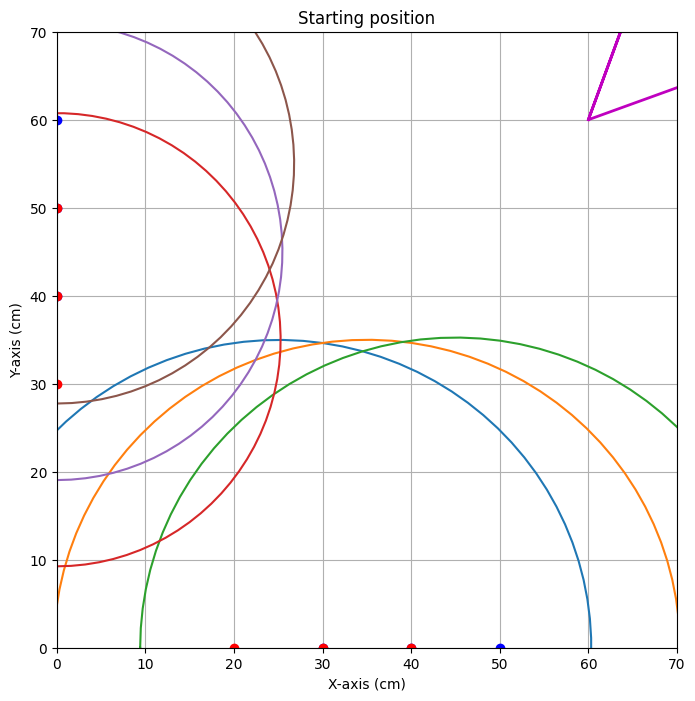


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=72.740


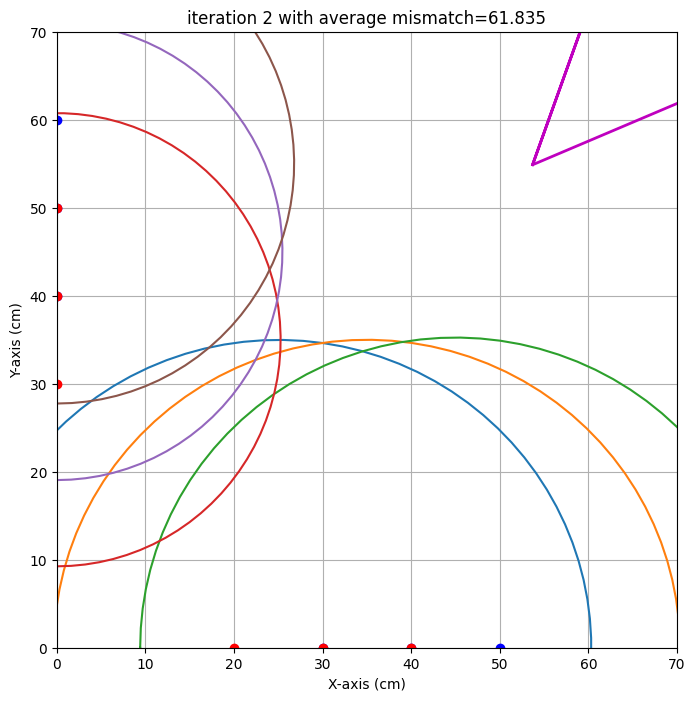

end iteration 2 with average mismatch=61.835


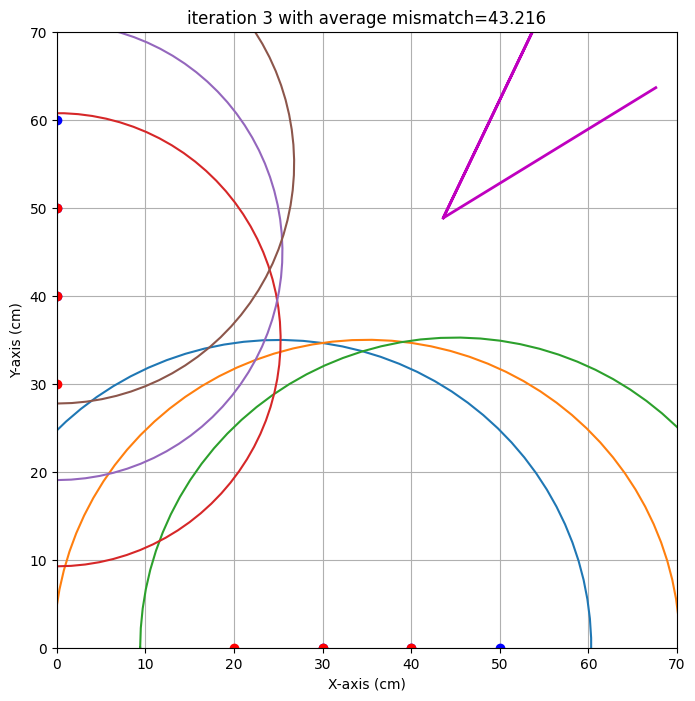

end iteration 3 with average mismatch=43.216


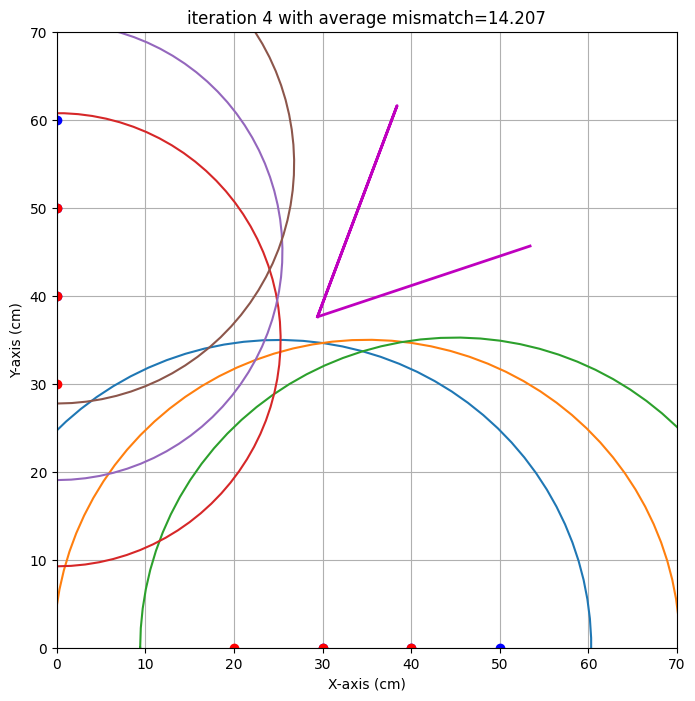

end iteration 4 with average mismatch=14.207


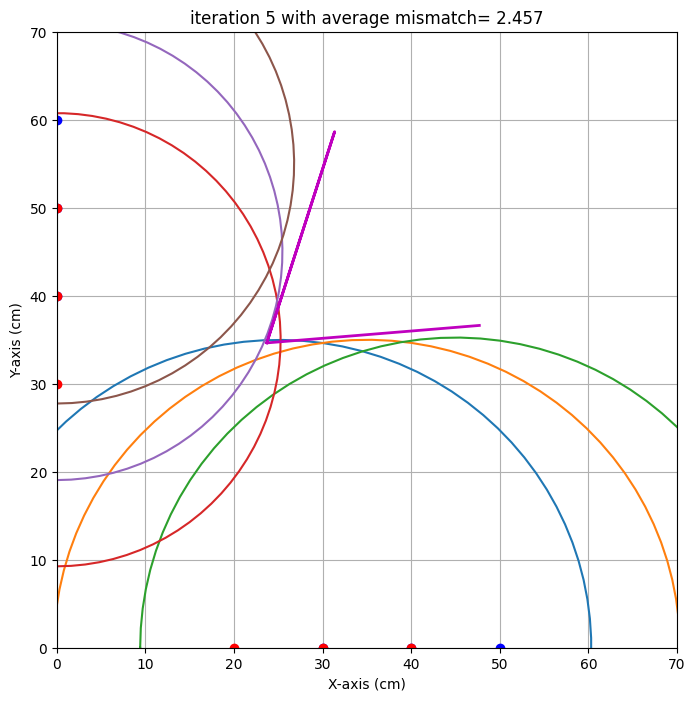

end iteration 5 with average mismatch= 2.457


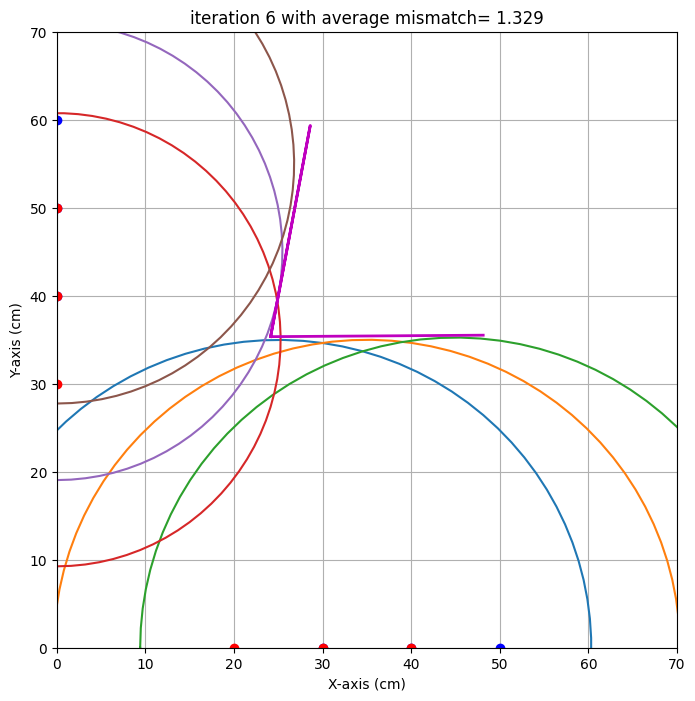

end iteration 6 with average mismatch= 1.329
end iteration 7 with average mismatch= 1.312
end iteration 8 with average mismatch= 1.311


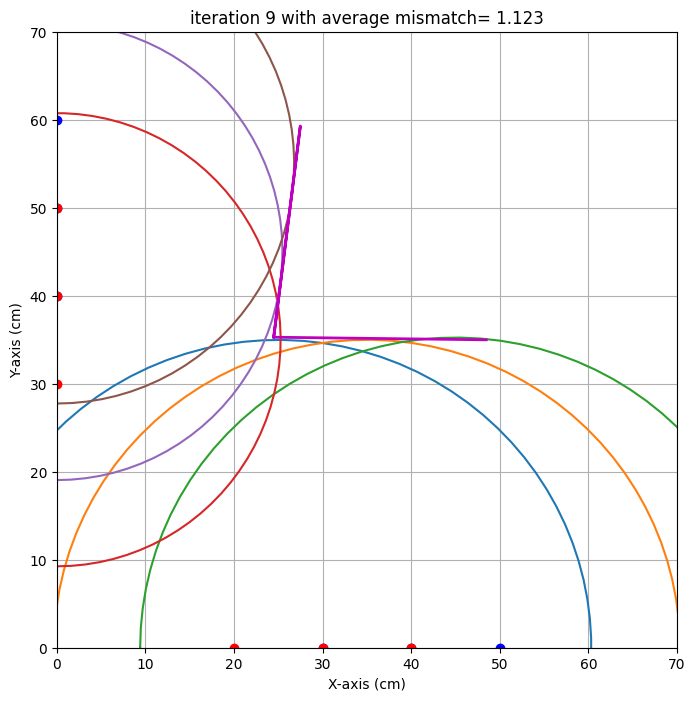

end iteration 9 with average mismatch= 1.123


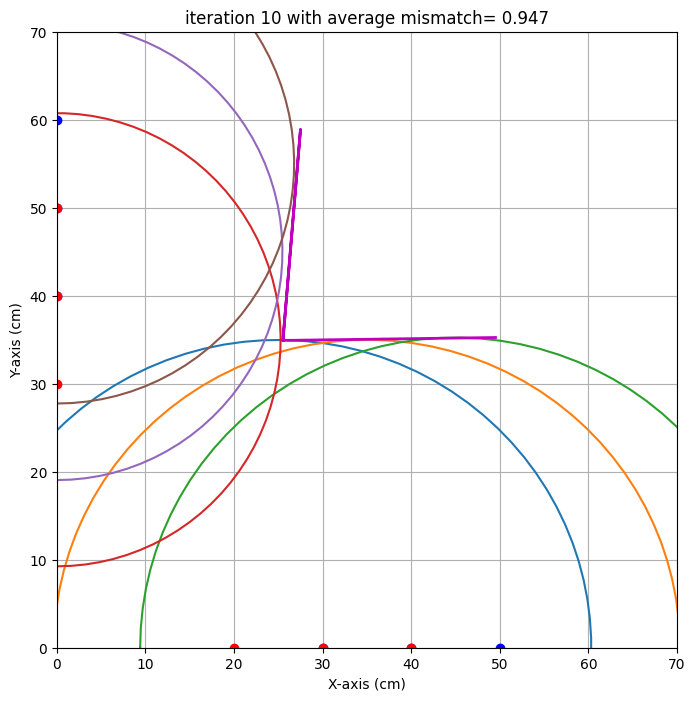

end iteration 10 with average mismatch= 0.947


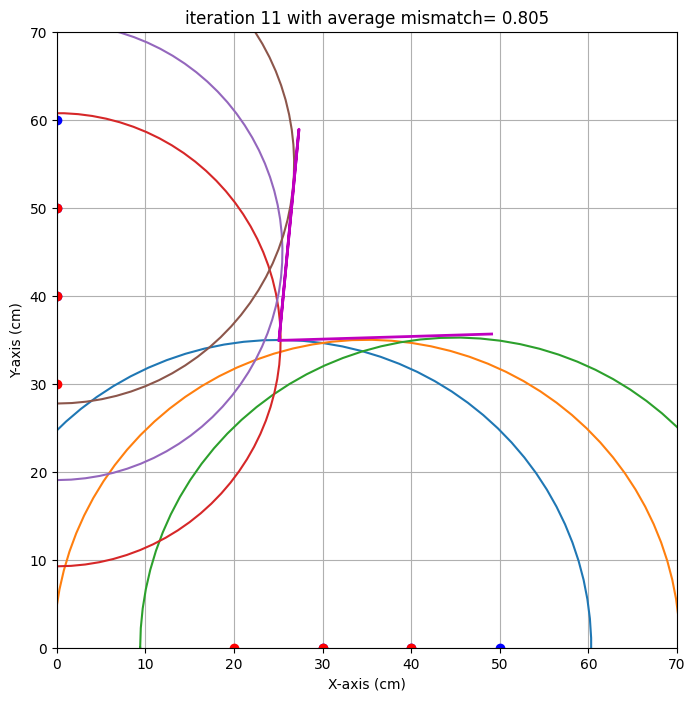

end iteration 11 with average mismatch= 0.805
end iteration 12 with average mismatch= 0.800
end iteration 13 with average mismatch= 0.796
end iteration 14 with average mismatch= 0.795
end iteration 15 with average mismatch= 0.782
end iteration 16 with average mismatch= 0.749
end iteration 17 with average mismatch= 0.737
end iteration 18 with average mismatch= 0.734
end iteration 19 with average mismatch= 0.734


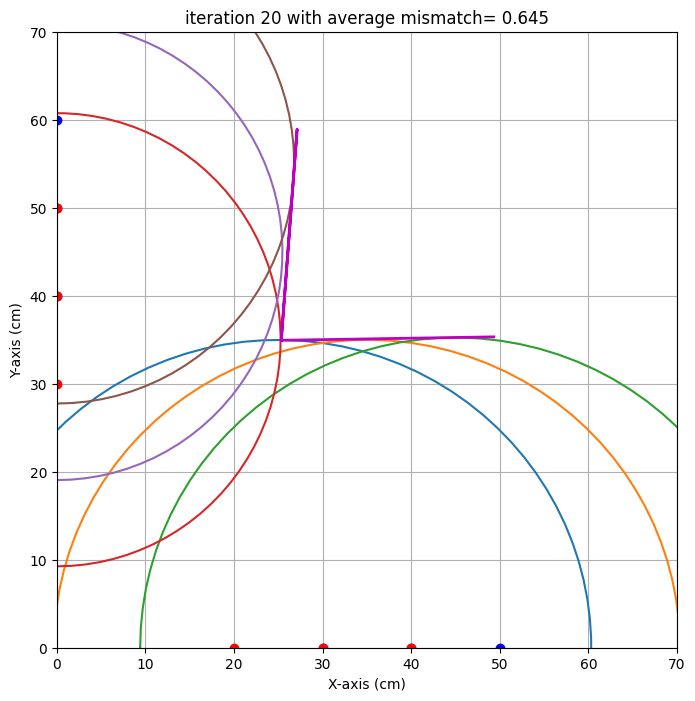

end iteration 20 with average mismatch= 0.645
end iteration 21 with average mismatch= 0.644
end iteration 22 with average mismatch= 0.644
end iteration 23 with average mismatch= 0.644
end iteration 24 with average mismatch= 0.644
end iteration 25 with average mismatch= 0.644
end iteration 26 with average mismatch= 0.644
end iteration 27 with average mismatch= 0.644
end iteration 28 with average mismatch= 0.644
end iteration 29 with average mismatch= 0.644
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.644
###############################################################################
end of iteration  30
Best alpha=   0.93 with uncertainty=   0.00
Best beta =   4.28 with uncertainty=   0.00
Best x0   =  25.33 with uncertainty=   0.00
Best y0   =  34.93 with uncertainty=   0.00
##########################################################

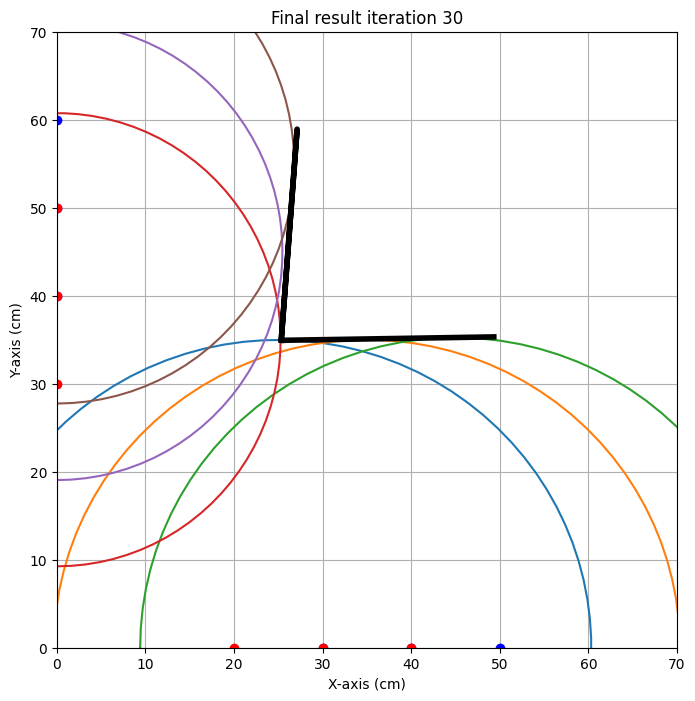

{'alpha': np.float64(0.9329958298136158), 'alpha_eps': 0.0, 'beta': np.float64(4.27785695418945), 'beta_eps': 0.0, 'x0': np.float64(25.327206702457094), 'x0_eps': 0.0, 'y0': np.float64(34.930895840280435), 'y0_eps': 0.0}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  20   0  30   0  42.76
1  30   0  40   0  42.28
2  40   0  50   0  44.00
3   0  20   0  30  47.40
4   0  30   0  40  44.80
5   0  40   0  50  48.60


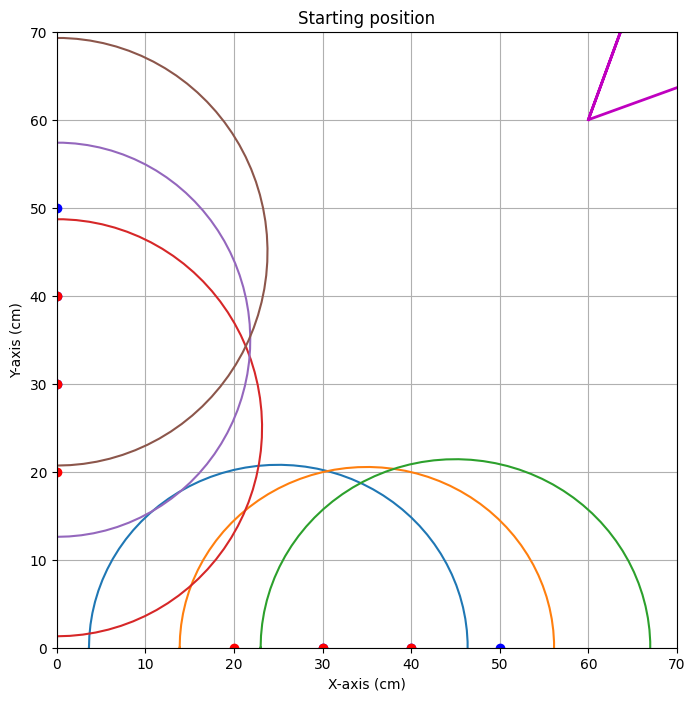


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=93.185


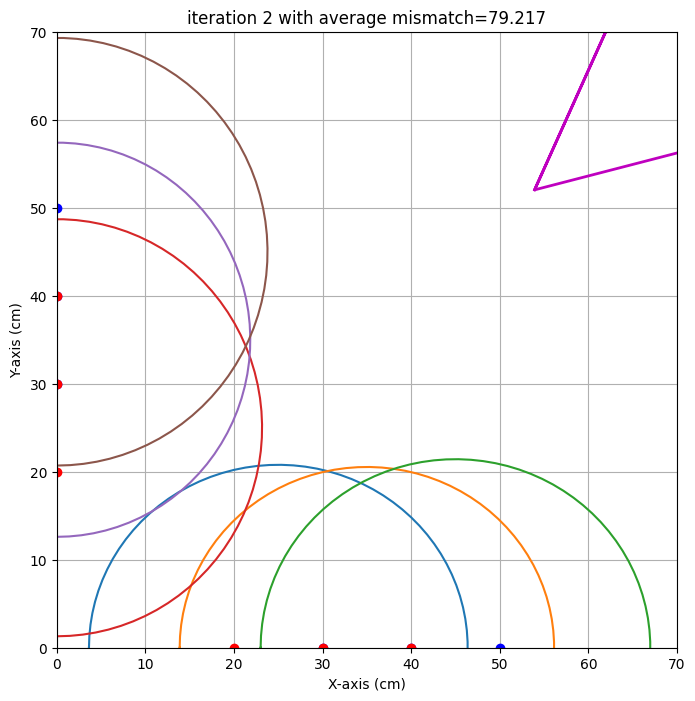

end iteration 2 with average mismatch=79.217


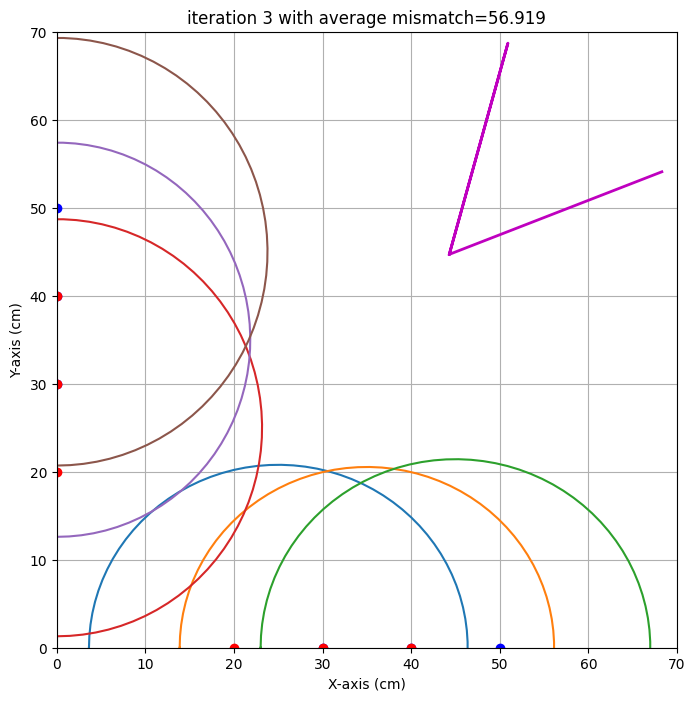

end iteration 3 with average mismatch=56.919


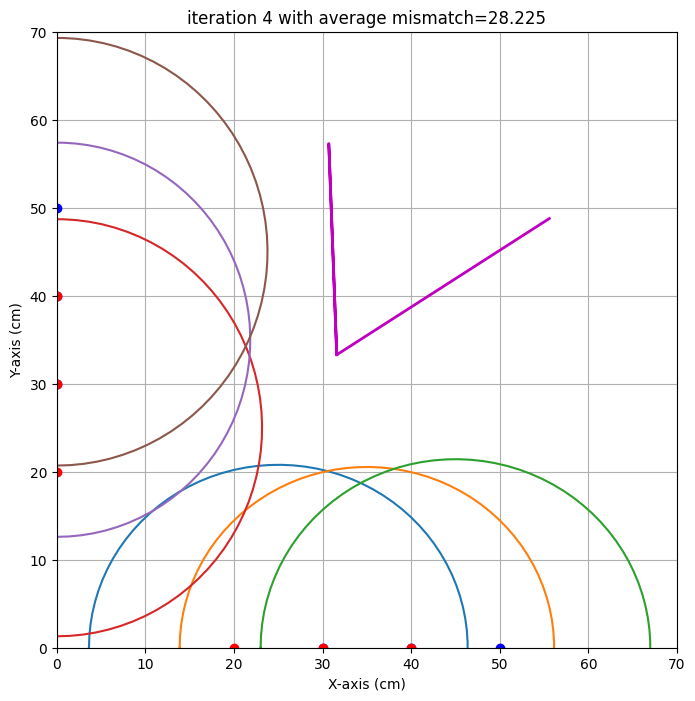

end iteration 4 with average mismatch=28.225


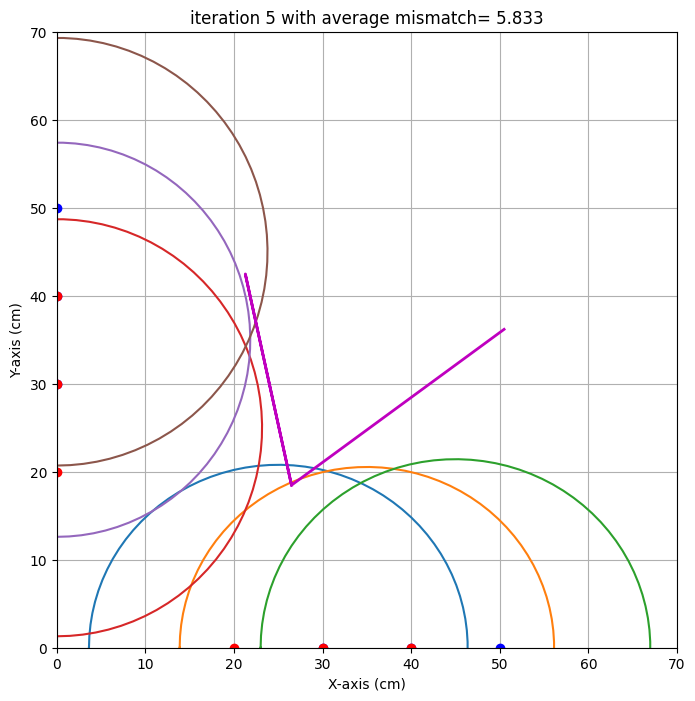

end iteration 5 with average mismatch= 5.833


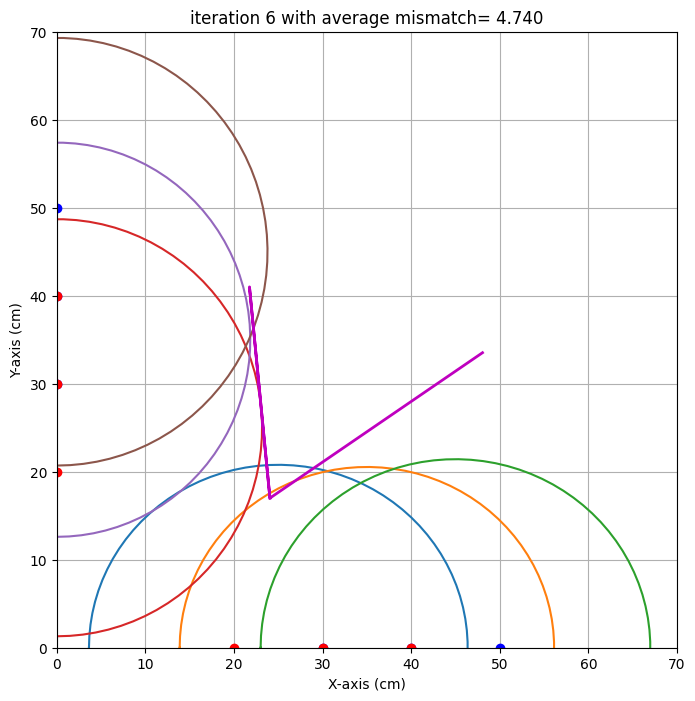

end iteration 6 with average mismatch= 4.740


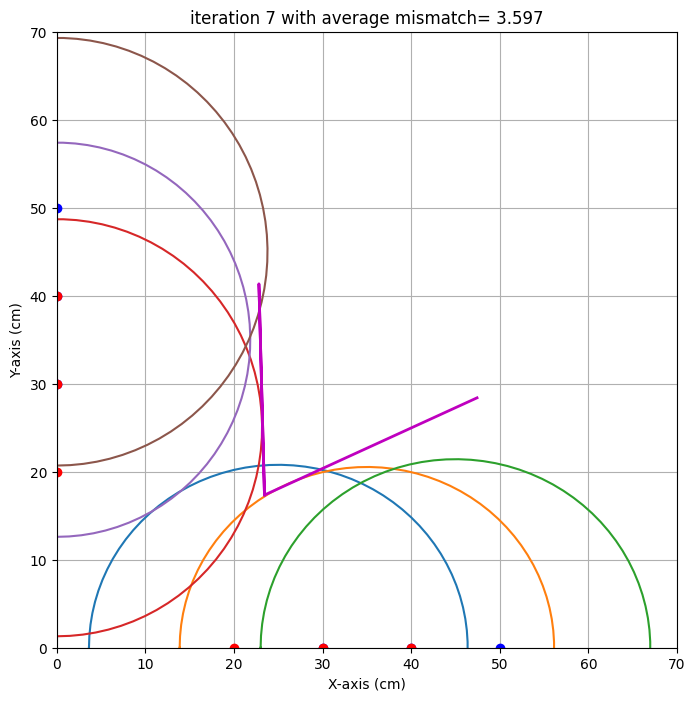

end iteration 7 with average mismatch= 3.597


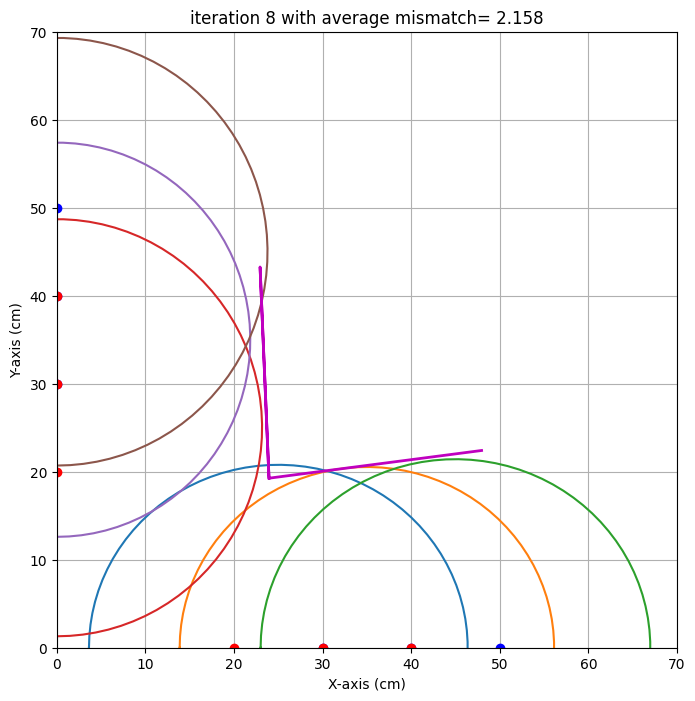

end iteration 8 with average mismatch= 2.158


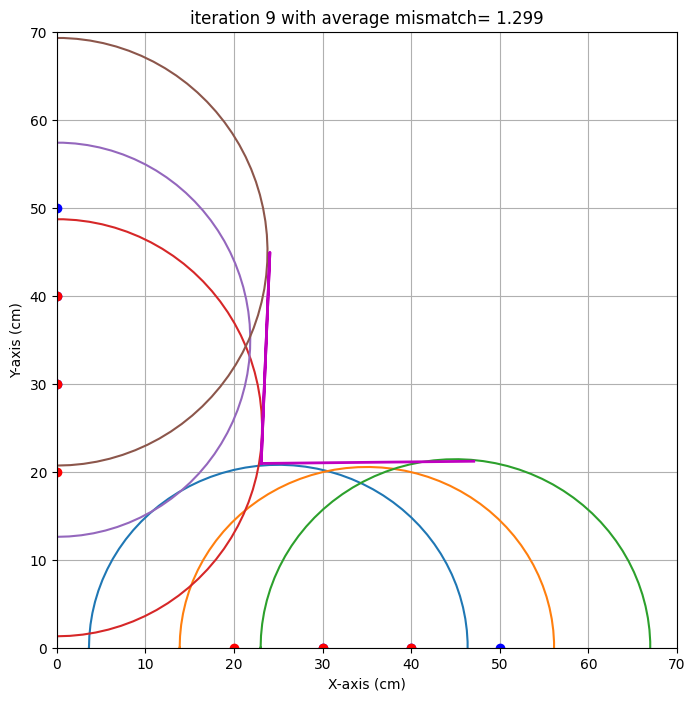

end iteration 9 with average mismatch= 1.299
end iteration 10 with average mismatch= 1.172
end iteration 11 with average mismatch= 1.172
end iteration 12 with average mismatch= 1.171
end iteration 13 with average mismatch= 1.159
end iteration 14 with average mismatch= 1.158
end iteration 15 with average mismatch= 1.057
end iteration 16 with average mismatch= 1.019
end iteration 17 with average mismatch= 1.016
end iteration 18 with average mismatch= 1.016
end iteration 19 with average mismatch= 1.015
end iteration 20 with average mismatch= 1.014
end iteration 21 with average mismatch= 1.014
end iteration 22 with average mismatch= 1.014
end iteration 23 with average mismatch= 1.014
end iteration 24 with average mismatch= 1.014
end iteration 25 with average mismatch= 1.014
end iteration 26 with average mismatch= 1.014
end iteration 27 with average mismatch= 1.014
end iteration 28 with average mismatch= 1.014
end iteration 29 with average mismatch= 1.014
Last iteration, also determine unce

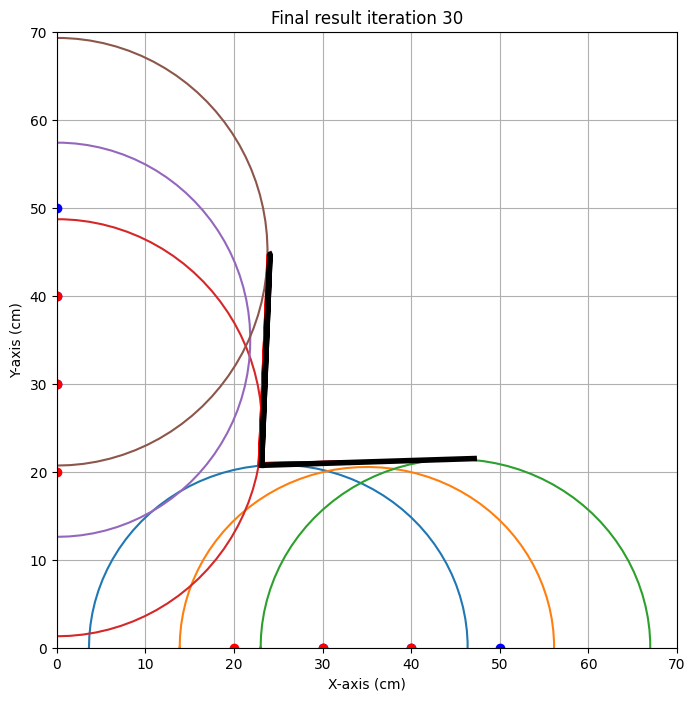

{'alpha': np.float64(1.8261876627710052), 'alpha_eps': np.float64(0.6985321121881447), 'beta': np.float64(2.2715369364929057), 'beta_eps': np.float64(0.22582516087415527), 'x0': np.float64(23.106523721463017), 'x0_eps': np.float64(0.3789683205476351), 'y0': np.float64(20.730083813234668), 'y0_eps': np.float64(0.29614990301404376)}
locatie 3
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  30   0  40  91.2
1   0  40   0  50  90.6
2   0  50   0  60  93.0
3  50   0  60   0  79.6
4  55   0  65   0  82.5
5  60   0  70   0  84.3


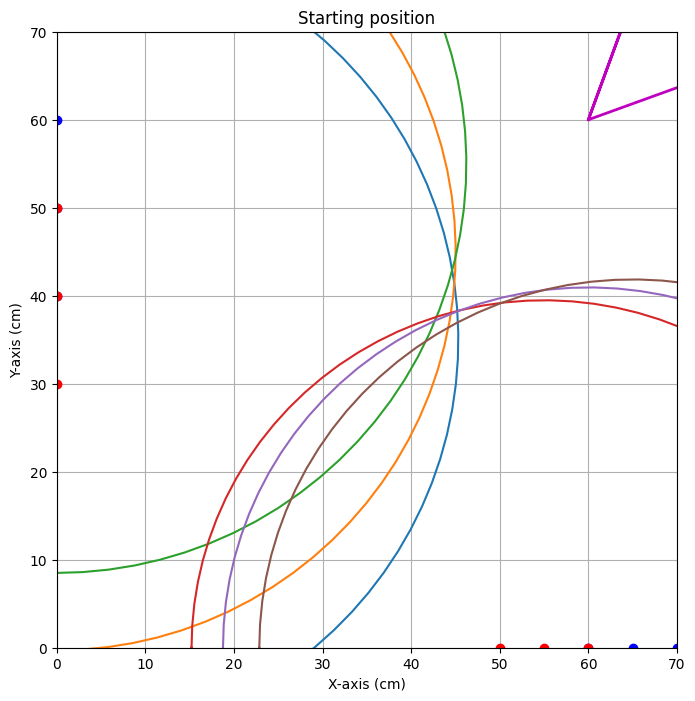


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=42.352


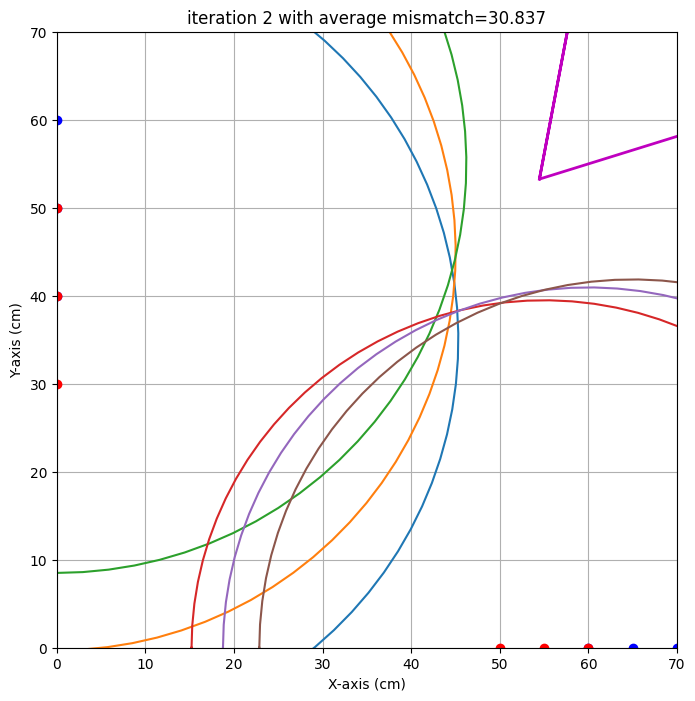

end iteration 2 with average mismatch=30.837


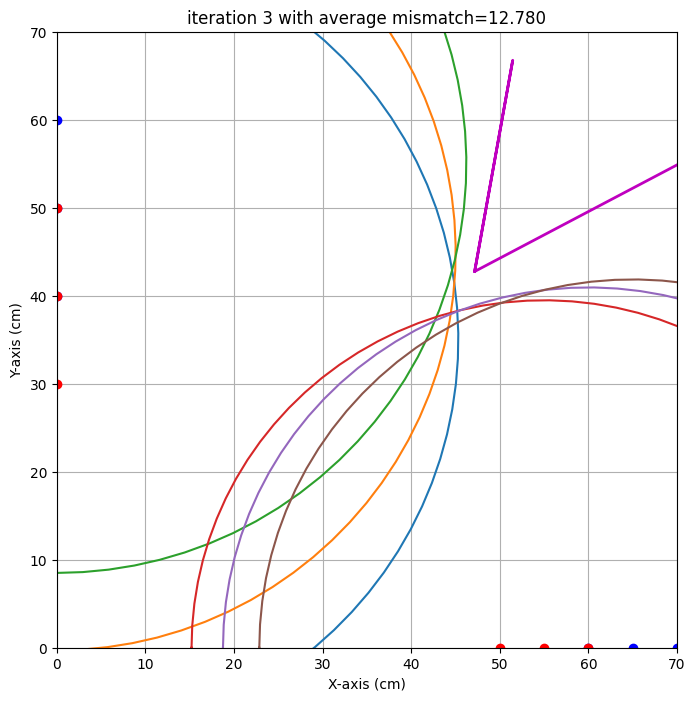

end iteration 3 with average mismatch=12.780


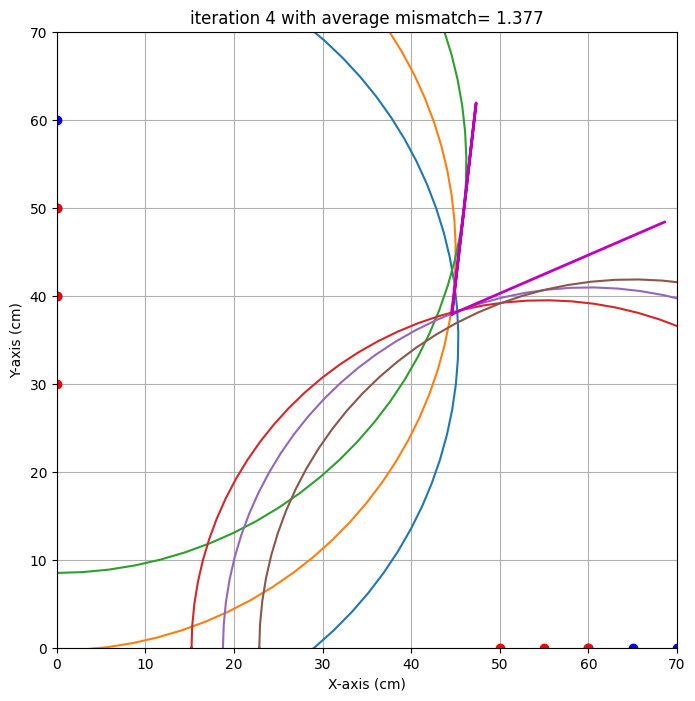

end iteration 4 with average mismatch= 1.377
end iteration 5 with average mismatch= 1.377
end iteration 6 with average mismatch= 1.343


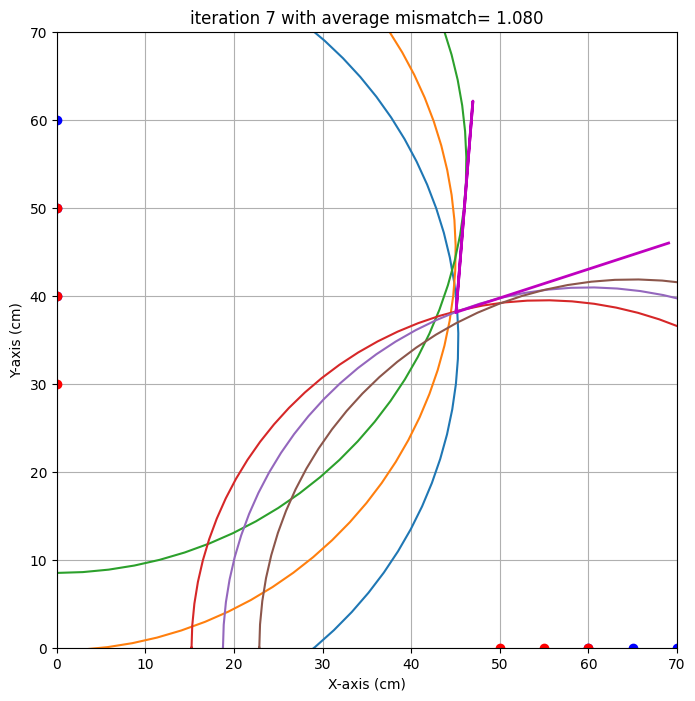

end iteration 7 with average mismatch= 1.080
end iteration 8 with average mismatch= 1.075
end iteration 9 with average mismatch= 1.074
end iteration 10 with average mismatch= 0.991
end iteration 11 with average mismatch= 0.933


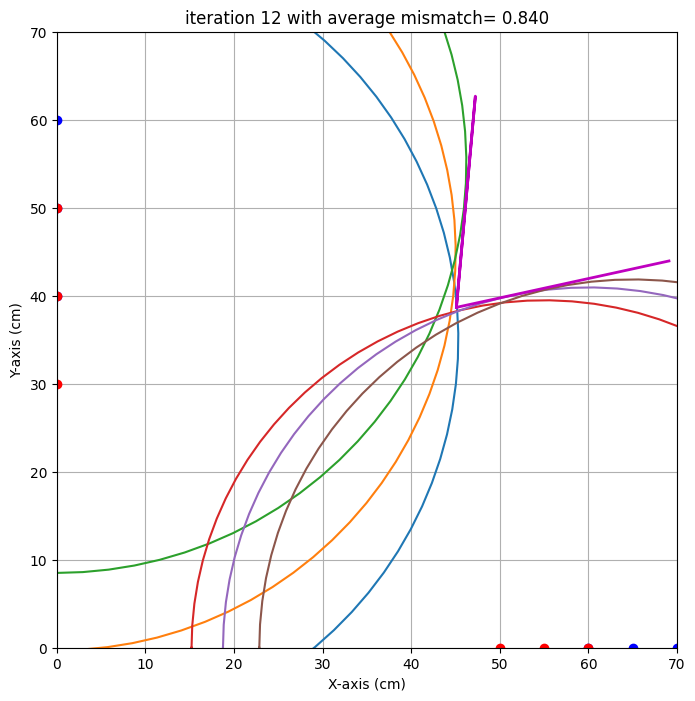

end iteration 12 with average mismatch= 0.840
end iteration 13 with average mismatch= 0.818
end iteration 14 with average mismatch= 0.817
end iteration 15 with average mismatch= 0.817
end iteration 16 with average mismatch= 0.817
end iteration 17 with average mismatch= 0.817
end iteration 18 with average mismatch= 0.808
end iteration 19 with average mismatch= 0.788
end iteration 20 with average mismatch= 0.787
end iteration 21 with average mismatch= 0.786
end iteration 22 with average mismatch= 0.786
end iteration 23 with average mismatch= 0.786
end iteration 24 with average mismatch= 0.786
end iteration 25 with average mismatch= 0.786
end iteration 26 with average mismatch= 0.786
end iteration 27 with average mismatch= 0.786
end iteration 28 with average mismatch= 0.786
end iteration 29 with average mismatch= 0.786
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.786
#################

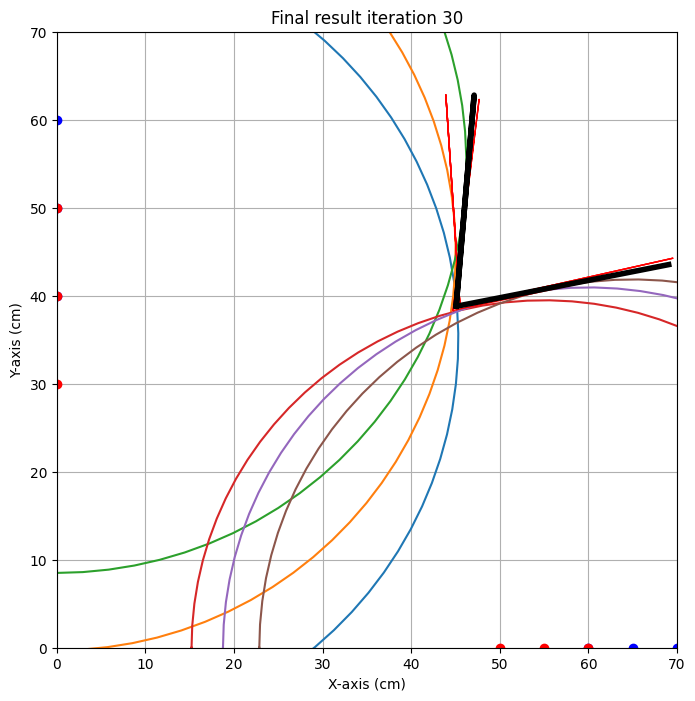

{'alpha': np.float64(11.176379054439261), 'alpha_eps': np.float64(1.5495902000519504), 'beta': np.float64(4.84671498422744), 'beta_eps': np.float64(8.655244051668722), 'x0': np.float64(45.07216304551884), 'x0_eps': np.float64(0.43530884506386514), 'y0': np.float64(38.794691355290304), 'y0_eps': np.float64(0.47300388594982223)}
locatie 1 
x0 target is : 34.6. Gevonden waarde: 25.3 cm met een standaardafwijking van 0.0 cm 
y0 target is : 25.0. Gevonden waarde: 34.9 cm met een standaardafwijking van 0.0 cm 
alpha target is : 0.0. Gevonden waarde: 0.9 graden met een standaardafwijking van 0.0 graad 
beta target is : 4.0. Gevonden waarde: 4.3 graden met een standaardafwijking van 0.0 graad 

locatie 2 
x0 target is : 20.0. Gevonden waarde: 23.1 cm met een standaardafwijking van 0.4 cm 
y0 target is : 25.0. Gevonden waarde: 20.7 cm met een standaardafwijking van 0.3 cm 
alpha target is : 0.0. Gevonden waarde: 1.8 graden met een standaardafwijking van 0.7 graad 
beta target is : 10.0. Gevonde

In [12]:
# Voeg hier je meetgegevens van deze iteratie in:
#________________locatie 1 is iteratie 1 locatie 2 is iteratie 2 .etc_______________________


# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':34.6,#zelf aanvullen,
                    'y0':25, #zelf aanvullen,
                    'alpha' :0, #zelf aanvullen,
                    'beta' :4, #zelf aanvullen}, 
},
           'locatie 2':{'x0':20,#zelf aanvullen,
                    'y0':25, #zelf aanvullen,
                    'alpha' :0, #zelf aanvullen,
                    'beta' :10, #zelf aanvullen
},
            'locatie 3':{
                    'x0': 44,  # zelf aanvullen,
                    'y0': 37,  # zelf aanvullen,
                    'alpha' :10,  # zelf aanvullen,
                    'beta' :11,  # zelf aanvullen
            }}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    [20,0,30,0,70.67],
    [30,0,40,0,70.7],
    [40,0,50,0,71.2],
    #[50,0,60,0,76.6],
    #[0,20,0,30,0],
    [0,30,0,40,51.5],
    [0,40,0,50,51.9],
    [0,50,0,60,54.5],
    
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [20,0,30,0,42.76],
    [30,0,40,0,42.28],
    [40,0,50,0,44.0],
    #[50,0,60,0,51.4],
    [0,20,0,30,47.40],
    [0,30,0,40,44.80],
    [0,40,0,50,48.6]
    #[0,50,0,60,0],
    ]),
       'locatie 3' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,30,0,40,91.2],
    [0,40,0,50,90.6],
    [0,50,0,60,93.0],
    [50,0,60,0,79.6],
    [55,0,65,0,82.5],
    [60,0,70,0,84.3],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))